<a href="https://colab.research.google.com/github/NanditaPatil-dotcom/PhysSAE/blob/main/PhysSAE_Additional_PDEs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Setup

In [ ]:
import os, time, math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.decomposition import PCA

# reproducibility
torch.manual_seed(0); np.random.seed(0)
torch.set_num_threads(4)

# publication style
mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 220,
    "font.family": "serif", "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.titlesize": 11, "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
})

os.makedirs("artifacts", exist_ok=True)
os.makedirs("figures", exist_ok=True)

# hyperparams
HIDDEN = 40        # PINN hidden width
N_LAYERS = 4       # number of hidden linear layers
DICT = 128         # SAE dictionary size (overcomplete 3.2x)
LAM_L1 = 5e-2      # SAE sparsity penalty
SAE_EPOCHS = 500
PINN_ITERS = 4000


# 2. PINN architecture


In [ ]:
class PINN(nn.Module):
    def __init__(self, out_dim=1, layers=None):
        super().__init__()

        layers = layers or ([2] +[HIDDEN]*N_LAYERS +[out_dim])

        self.net = nn.ModuleList(
            [nn.Linear(layers[i], layers[i+1])
             for i in range(len(layers)-1)]
        )

        self.act = nn.Tanh()

        for m in self.net:
            nn.init.xavier_normal_(m.weight)
            nn.init.zeros_(m.bias)

        self._hidden = None

    def forward(self,x,t):
        h = torch.cat([x,t],dim=1)

        for layer in self.net[:-1]:
            h = self.act(layer(h))

        self._hidden = h

        return self.net[-1](h)


# 3. Training PINN

In [ ]:
def train_pinn(loss_fn, n_iter=PINN_ITERS, log_every=400, tag="pinn",out_dim=1):
    model = PINN(out_dim=out_dim)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    hist = []; t0 = time.time()
    for it in range(n_iter):
        opt.zero_grad()
        loss, parts = loss_fn(model)
        loss.backward(); opt.step()
        hist.append(parts)
        if it % log_every == 0:
            print(f"[{tag}] it {it:5d} | bc {parts[0]:.2e} ic {parts[1]:.2e} f {parts[2]:.2e} | {time.time()-t0:.0f}s")
    print(f"[{tag}] total {time.time()-t0:.0f}s")
    return model, np.array(hist)

# 3. Train on PDEs

## 1. Train the Burgers PINN



In [ ]:
nu = 0.01/np.pi
def burgers_loss(model):
    n_b, n_i, n_f = 100, 100, 2500
    x_b1 = -torch.ones(n_b,1); x_b2 = torch.ones(n_b,1); t_b = torch.rand(n_b,1)
    x_i = torch.rand(n_i,1)*2-1; t_i = torch.zeros(n_i,1); u_i = -torch.sin(np.pi*x_i)
    x_f = torch.rand(n_f,1)*2-1; t_f = torch.rand(n_f,1)
    u_b1, u_b2, u_ip = model(x_b1, t_b), model(x_b2, t_b), model(x_i, t_i)
    xfg, tfg = x_f.clone().requires_grad_(True), t_f.clone().requires_grad_(True)
    u = model(xfg, tfg)
    u_t = torch.autograd.grad(u, tfg, torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, xfg, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, xfg, torch.ones_like(u_x), create_graph=True)[0]
    r = u_t + u*u_x - nu*u_xx
    l_bc = (u_b1**2).mean() + (u_b2**2).mean()
    l_ic = ((u_ip - u_i)**2).mean()
    l_f  = (r**2).mean()
    return 100*l_bc + 100*l_ic + l_f, (l_bc.item(), l_ic.item(), l_f.item())

if os.path.exists("artifacts/burgers_pinn.pt"):
    pinn_b = PINN(out_dim=1); pinn_b.load_state_dict(torch.load("artifacts/burgers_pinn.pt"))
    hist_b = np.load("artifacts/burgers_hist.npy")
    print("Loaded cached Burgers PINN.")
else:
    pinn_b, hist_b = train_pinn(burgers_loss, tag="burgers")
    torch.save(pinn_b.state_dict(), "artifacts/burgers_pinn.pt")
    np.save("artifacts/burgers_hist.npy", hist_b)


[burgers] it     0 | bc 4.46e-02 ic 6.66e-01 f 1.98e-02 | 0s
[burgers] it   400 | bc 2.62e-03 ic 5.68e-03 f 4.78e-01 | 38s
[burgers] it   800 | bc 3.61e-04 ic 6.24e-04 f 4.59e-01 | 83s
[burgers] it  1200 | bc 1.05e-04 ic 2.45e-04 f 3.97e-01 | 121s
[burgers] it  1600 | bc 2.51e-05 ic 1.61e-04 f 3.93e-01 | 159s
[burgers] it  2000 | bc 1.61e-04 ic 1.48e-04 f 3.34e-01 | 203s
[burgers] it  2400 | bc 9.10e-05 ic 1.49e-04 f 2.95e-01 | 255s
[burgers] it  2800 | bc 9.06e-05 ic 8.34e-05 f 3.09e-01 | 297s
[burgers] it  3200 | bc 6.78e-05 ic 1.61e-04 f 2.75e-01 | 338s
[burgers] it  3600 | bc 4.09e-05 ic 6.51e-05 f 2.72e-01 | 376s
[burgers] total 414s


## 2. Train the Allen–Cahn PINN


In [ ]:
D_AC = 1e-4
def allencahn_loss(model):
    n_b, n_i, n_f = 100, 100, 2500
    t_b = torch.rand(n_b,1)
    x_bl = -torch.ones(n_b,1); x_br = torch.ones(n_b,1)
    x_i = torch.rand(n_i,1)*2-1; t_i = torch.zeros(n_i,1)
    u_i = (x_i**2) * torch.cos(np.pi*x_i)
    x_f = torch.rand(n_f,1)*2-1; t_f = torch.rand(n_f,1)
    # periodic BC: u(-1,t)=u(1,t) and u_x(-1,t)=u_x(1,t)
    xbl_g, xbr_g = x_bl.clone().requires_grad_(True), x_br.clone().requires_grad_(True)
    u_bl, u_br = model(xbl_g, t_b), model(xbr_g, t_b)
    u_bl_x = torch.autograd.grad(u_bl, xbl_g, torch.ones_like(u_bl), create_graph=True)[0]
    u_br_x = torch.autograd.grad(u_br, xbr_g, torch.ones_like(u_br), create_graph=True)[0]
    l_bc = ((u_bl-u_br)**2).mean() + ((u_bl_x-u_br_x)**2).mean()
    u_ip = model(x_i, t_i); l_ic = ((u_ip - u_i)**2).mean()
    xfg, tfg = x_f.clone().requires_grad_(True), t_f.clone().requires_grad_(True)
    u = model(xfg, tfg)
    u_t = torch.autograd.grad(u, tfg, torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, xfg, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, xfg, torch.ones_like(u_x), create_graph=True)[0]
    r = u_t - D_AC*u_xx + 5.0*u**3 - 5.0*u
    l_f = (r**2).mean()
    return 100*l_bc + 100*l_ic + l_f, (l_bc.item(), l_ic.item(), l_f.item())

if os.path.exists("artifacts/allencahn_pinn.pt"):
    pinn_a = PINN(out_dim=1); pinn_a.load_state_dict(torch.load("artifacts/allencahn_pinn.pt"))
    hist_a = np.load("artifacts/allencahn_hist.npy")
    print("Loaded cached Allen-Cahn PINN.")
else:
    pinn_a, hist_a = train_pinn(allencahn_loss, tag="allencahn")
    torch.save(pinn_a.state_dict(), "artifacts/allencahn_pinn.pt")
    np.save("artifacts/allencahn_hist.npy", hist_a)


[allencahn] it     0 | bc 4.76e-02 ic 1.68e-01 f 1.10e-01 | 0s
[allencahn] it   400 | bc 1.09e-03 ic 2.27e-02 f 1.09e+00 | 38s
[allencahn] it   800 | bc 3.51e-04 ic 1.28e-02 f 9.96e-01 | 76s
[allencahn] it  1200 | bc 2.83e-03 ic 8.89e-03 f 9.47e-01 | 114s
[allencahn] it  1600 | bc 2.40e-03 ic 4.50e-03 f 1.00e+00 | 152s
[allencahn] it  2000 | bc 1.74e-03 ic 3.84e-03 f 1.02e+00 | 189s
[allencahn] it  2400 | bc 4.48e-04 ic 2.39e-03 f 9.88e-01 | 227s
[allencahn] it  2800 | bc 8.51e-04 ic 1.74e-03 f 1.09e+00 | 264s
[allencahn] it  3200 | bc 2.09e-04 ic 2.39e-03 f 8.92e-01 | 301s
[allencahn] it  3600 | bc 5.60e-04 ic 1.78e-03 f 9.40e-01 | 338s
[allencahn] total 376s


## 3. Heat Equation

In [ ]:
def heat_loss(model):
    n_b, n_i, n_f = 100, 100, 2500
    x_b1 = -torch.ones(n_b,1)
    x_b2 =  torch.ones(n_b,1)
    t_b = torch.rand(n_b,1)
    u_b1 = model(x_b1, t_b)
    u_b2 = model(x_b2, t_b)
    x_i = 2*torch.rand(n_i,1) - 1
    t_i = torch.zeros(n_i,1)
    u_i_true = torch.exp(-5*x_i**2)
    u_i = model(x_i, t_i)
    x_f = 2*torch.rand(n_f,1) - 1
    t_f = torch.rand(n_f,1)
    xfg = x_f.clone().requires_grad_(True)
    tfg = t_f.clone().requires_grad_(True)
    u = model(xfg, tfg)
    u_t = torch.autograd.grad(u,tfg,torch.ones_like(u),create_graph=True)[0]
    u_x = torch.autograd.grad(u,xfg,torch.ones_like(u),create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x,xfg,torch.ones_like(u_x),create_graph=True)[0]

    r = u_t - u_xx

    l_bc = (u_b1**2).mean() + (u_b2**2).mean()
    l_ic = ((u_i - u_i_true)**2).mean()
    l_f = (r**2).mean()
    total = 100*l_bc + 100*l_ic + l_f
    return total, (l_bc.item(),l_ic.item(),l_f.item())

if os.path.exists("artifacts/heat_pinn.pt"):
    pinn_h = PINN(out_dim=1)
    pinn_h.load_state_dict(torch.load("artifacts/heat_pinn.pt"))
    hist_h = np.load("artifacts/heat_hist.npy")
    print("Loaded cached Heat PINN.")
else:
    pinn_h, hist_h = train_pinn(heat_loss,tag="heat")
    torch.save(pinn_h.state_dict(),"artifacts/heat_pinn.pt")
    np.save("artifacts/heat_hist.npy",hist_h)

[heat] it     0 | bc 1.37e-01 ic 3.09e-01 f 3.02e-02 | 0s
[heat] it   400 | bc 6.86e-04 ic 3.01e-03 f 4.05e-01 | 35s
[heat] it   800 | bc 3.57e-04 ic 7.17e-04 f 1.92e-01 | 69s
[heat] it  1200 | bc 1.54e-04 ic 2.32e-04 f 1.07e-01 | 105s
[heat] it  1600 | bc 1.18e-04 ic 2.47e-04 f 5.35e-02 | 140s
[heat] it  2000 | bc 3.77e-05 ic 1.45e-04 f 3.65e-02 | 174s
[heat] it  2400 | bc 5.39e-05 ic 9.66e-05 f 2.83e-02 | 210s
[heat] it  2800 | bc 2.37e-05 ic 6.48e-05 f 1.61e-02 | 246s
[heat] it  3200 | bc 4.17e-05 ic 4.90e-05 f 1.60e-02 | 282s
[heat] it  3600 | bc 2.68e-04 ic 9.32e-05 f 1.44e-02 | 317s
[heat] total 351s


## 4. schrodinger equation

In [ ]:
def schrodinger_loss(model):

    n_b, n_i, n_f = 100, 100, 2500
    x_b1 = -5*torch.ones(n_b,1)
    x_b2 =  5*torch.ones(n_b,1)
    t_b  = torch.rand(n_b,1)
    uv_b1 = model(x_b1,t_b)
    uv_b2 = model(x_b2,t_b)
    u_b1 = uv_b1[:,0:1]
    v_b1 = uv_b1[:,1:2]
    u_b2 = uv_b2[:,0:1]
    v_b2 = uv_b2[:,1:2]
    x_i = -5 + 10*torch.rand(n_i,1)
    t_i = torch.zeros(n_i,1)

    uv_i = model(x_i,t_i)

    u_i = uv_i[:,0:1]
    v_i = uv_i[:,1:2]

    eta = 2.0
    v0  = 2.0

    amp0 = eta / torch.cosh(eta*x_i)

    u_true = amp0 * torch.cos(v0*x_i)
    v_true = amp0 * torch.sin(v0*x_i)

    """
    single soliton code :
     x_i = -5 + 10*torch.rand(n_i,1)
     t_i = torch.zeros(n_i,1)

     uv_i = model(x_i,t_i)

     u_i = uv_i[:,0:1]
     v_i = uv_i[:,1:2]

     u_true = 2.0 / torch.cosh(x_i)
     v_true = torch.zeros_like(x_i)
     """
    x_f = -5 + 10*torch.rand(n_f,1)
    t_f = torch.rand(n_f,1)
    xfg = x_f.clone().requires_grad_(True)
    tfg = t_f.clone().requires_grad_(True)
    uv = model(xfg,tfg)
    u = uv[:,0:1]
    v = uv[:,1:2]

    u_t = torch.autograd.grad(u, tfg,torch.ones_like(u),create_graph=True)[0]
    v_t = torch.autograd.grad(v, tfg,torch.ones_like(v),create_graph=True)[0]
    u_x = torch.autograd.grad(u, xfg,torch.ones_like(u),create_graph=True)[0]
    v_x = torch.autograd.grad(v, xfg,torch.ones_like(v),create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, xfg,torch.ones_like(u_x),create_graph=True)[0]
    v_xx = torch.autograd.grad(v_x, xfg,torch.ones_like(v_x),create_graph=True)[0]
    amp2 = u*u + v*v
    r_u = u_t + 0.5*v_xx + amp2*v
    r_v = v_t - 0.5*u_xx - amp2*u
    l_bc = ((u_b1**2).mean()+ (v_b1**2).mean()+ (u_b2**2).mean()+ (v_b2**2).mean())
    l_ic = (((u_i-u_true)**2).mean()+ ((v_i-v_true)**2).mean())
    l_f = ((r_u**2).mean()+ (r_v**2).mean())
    total = 100*l_bc + 100*l_ic + l_f

    return total, (l_bc.item(),l_ic.item(),l_f.item())


if os.path.exists("artifacts/schrodinger_pinn.pt"):
    pinn_s = PINN(out_dim=2)
    pinn_s.load_state_dict(torch.load("artifacts/schrodinger_pinn.pt"))
    hist_s = np.load("artifacts/schrodinger_hist.npy")
    print("Loaded cached Schrödinger PINN.")

else:
    pinn_s, hist_s = train_pinn(schrodinger_loss,tag="schrodinger",out_dim=2)
    torch.save(pinn_s.state_dict(),"artifacts/schrodinger_pinn.pt")
    np.save("artifacts/schrodinger_hist.npy",hist_s)

[schrodinger] it     0 | bc 3.15e+00 ic 1.41e+00 f 1.71e+00 | 0s
[schrodinger] it   400 | bc 1.41e-03 ic 5.74e-02 f 7.26e-01 | 67s
[schrodinger] it   800 | bc 6.05e-04 ic 6.15e-03 f 5.62e-01 | 135s
[schrodinger] it  1200 | bc 2.88e-04 ic 2.73e-03 f 3.86e-01 | 201s
[schrodinger] it  1600 | bc 1.46e-04 ic 2.08e-03 f 2.81e-01 | 268s
[schrodinger] it  2000 | bc 1.23e-04 ic 9.41e-04 f 2.35e-01 | 334s
[schrodinger] it  2400 | bc 9.27e-05 ic 6.22e-04 f 1.88e-01 | 401s
[schrodinger] it  2800 | bc 5.13e-05 ic 3.08e-04 f 1.43e-01 | 466s
[schrodinger] it  3200 | bc 6.91e-05 ic 2.13e-04 f 1.40e-01 | 533s
[schrodinger] it  3600 | bc 4.85e-05 ic 1.36e-04 f 1.13e-01 | 599s
[schrodinger] total 667s


## 5. Convection equation

In [ ]:
def convection_loss(model, beta):

    n_b, n_i, n_f = 100, 100, 2500

    # periodic BC
    t_b = torch.rand(n_b,1)
    x_bl = -torch.ones(n_b,1)
    x_br =  torch.ones(n_b,1)
    u_bl = model(x_bl, t_b)
    u_br = model(x_br, t_b)

    # periodic derivative BC
    xbl_g = x_bl.clone().requires_grad_(True)
    xbr_g = x_br.clone().requires_grad_(True)

    u_bl_g = model(xbl_g, t_b)
    u_br_g = model(xbr_g, t_b)

    u_bl_x = torch.autograd.grad(u_bl_g,xbl_g,torch.ones_like(u_bl_g),create_graph=True)[0]
    u_br_x = torch.autograd.grad(u_br_g,xbr_g,torch.ones_like(u_br_g),create_graph=True)[0]
    l_bc = ((u_bl - u_br)**2).mean() + ((u_bl_x - u_br_x)**2).mean()

    # initial condition

    x_i = 2*torch.rand(n_i,1) - 1
    t_i = torch.zeros(n_i,1)

    u_true = torch.sin(np.pi*x_i)

    u_i = model(x_i,t_i)

    l_ic = ((u_i - u_true)**2).mean()

    # residual points

    x_f = 2*torch.rand(n_f,1) - 1
    t_f = torch.rand(n_f,1)

    xfg = x_f.clone().requires_grad_(True)
    tfg = t_f.clone().requires_grad_(True)

    u = model(xfg,tfg)
    u_t = torch.autograd.grad(u,tfg,torch.ones_like(u),create_graph=True)[0]
    u_x = torch.autograd.grad(u,xfg,torch.ones_like(u),create_graph=True)[0]

    r = u_t + beta*u_x
    l_f = (r**2).mean()
    total = 100*l_bc + 100*l_ic + l_f
    return total, (l_bc.item(),l_ic.item(),l_f.item())

In [ ]:
BETAS = [1,10,30,50]

conv_models = {}
conv_hists  = {}

for beta in BETAS:

    fname_model = f"artifacts/convection_beta{beta}.pt"
    fname_hist  = f"artifacts/convection_beta{beta}_hist.npy"

    if os.path.exists(fname_model):

        model = PINN(out_dim=1)
        model.load_state_dict(torch.load(fname_model))
        hist = np.load(fname_hist)
        print(f"Loaded cached convection PINN beta={beta}")

    else:

        loss_fn = lambda m, b=beta: convection_loss(m,b)
        model, hist = train_pinn(loss_fn,tag=f"conv_beta{beta}")
        torch.save(model.state_dict(),fname_model)
        np.save(fname_hist,hist)

    conv_models[beta] = model
    conv_hists[beta]  = hist

[conv_beta1] it     0 | bc 7.94e-03 ic 5.03e-01 f 2.38e-02 | 0s
[conv_beta1] it   400 | bc 1.39e-03 ic 3.66e-03 f 9.86e-01 | 25s
[conv_beta1] it   800 | bc 4.77e-04 ic 1.30e-03 f 7.70e-01 | 50s
[conv_beta1] it  1200 | bc 1.55e-04 ic 5.87e-04 f 6.71e-01 | 74s
[conv_beta1] it  1600 | bc 3.53e-04 ic 5.54e-04 f 5.24e-01 | 100s
[conv_beta1] it  2000 | bc 1.01e-03 ic 8.68e-04 f 4.61e-01 | 124s
[conv_beta1] it  2400 | bc 1.11e-03 ic 9.82e-05 f 4.04e-01 | 148s
[conv_beta1] it  2800 | bc 2.24e-04 ic 9.60e-05 f 3.30e-01 | 174s
[conv_beta1] it  3200 | bc 2.01e-04 ic 9.07e-05 f 2.78e-01 | 198s
[conv_beta1] it  3600 | bc 5.77e-05 ic 1.49e-04 f 2.24e-01 | 224s
[conv_beta1] total 250s
[conv_beta10] it     0 | bc 3.69e-02 ic 4.31e-01 f 6.82e-01 | 0s
[conv_beta10] it   400 | bc 1.99e-02 ic 1.72e-02 f 4.17e+00 | 27s
[conv_beta10] it   800 | bc 9.93e-03 ic 1.01e-02 f 2.88e+00 | 52s
[conv_beta10] it  1200 | bc 6.28e-03 ic 3.91e-03 f 2.55e+00 | 78s
[conv_beta10] it  1600 | bc 4.95e-03 ic 3.48e-03 f 1.90e+0

# 4. Evaluate All PINNs on a dense grid



In [ ]:
nx, nt = 256, 100
xs = torch.linspace(-1, 1, nx).reshape(-1,1)
ts = torch.linspace(0, 1, nt).reshape(-1,1)
X, T = torch.meshgrid(xs.squeeze(), ts.squeeze(), indexing='ij')
XF, TF = X.reshape(-1,1), T.reshape(-1,1)
np.save("artifacts/grid_x.npy", xs.numpy().squeeze())
np.save("artifacts/grid_t.npy", ts.numpy().squeeze())

def eval_pinn_and_hidden(model):
    with torch.no_grad():
        U = model(XF, TF).reshape(nx, nt).numpy()
        H = model._hidden.detach().reshape(nx, nt, HIDDEN).numpy()
    return U, H

def eval_schrodinger_and_hidden(model):

    with torch.no_grad():
        UV = model(XF,TF)
        U = UV[:,0].reshape(nx,nt).numpy()
        V = UV[:,1].reshape(nx,nt).numpy()
        H = (model._hidden.detach().reshape(nx,nt,HIDDEN).numpy())
    return U,V,H

U_b, H_b = eval_pinn_and_hidden(pinn_b)
np.save("artifacts/burgers_U.npy", U_b)
np.save("artifacts/burgers_H.npy", H_b)

U_a, H_a = eval_pinn_and_hidden(pinn_a)
np.save("artifacts/allencahn_U.npy", U_a)
np.save("artifacts/allencahn_H.npy", H_a)

U_h, H_h = eval_pinn_and_hidden(pinn_h)
np.save("artifacts/heat_U.npy",U_h)
np.save("artifacts/heat_H.npy",H_h)

U_s, V_s, H_s = eval_schrodinger_and_hidden(pinn_s)
np.save("artifacts/schrodinger_u.npy", U_s)
np.save("artifacts/schrodinger_v.npy", V_s)
np.save("artifacts/schrodinger_H.npy", H_s)
AMP_s = np.sqrt(U_s**2 + V_s**2)
np.save("artifacts/schrodinger_amp.npy",AMP_s)
PHI_s = np.arctan2(V_s, U_s)
np.save("artifacts/schrodinger_phi.npy",PHI_s)

# Successful convection (beta=1)
U_c1, H_c1 = eval_pinn_and_hidden(conv_models[1])
np.save("artifacts/convection_beta1_U.npy", U_c1)
np.save("artifacts/convection_beta1_H.npy", H_c1)

# Failed convection (beta=50)
U_c50, H_c50 = eval_pinn_and_hidden(conv_models[50])
np.save("artifacts/convection_beta50_U.npy", U_c50)
np.save("artifacts/convection_beta50_H.npy", H_c50)

print(f"Burgers   U range [{U_b.min():.3f}, {U_b.max():.3f}], H shape {H_b.shape}")
print(f"AllenCahn U range [{U_a.min():.3f}, {U_a.max():.3f}], H shape {H_a.shape}")
print(f"Heat     U range "f"[{U_h.min():.3f}, {U_h.max():.3f}], "f"H shape {H_h.shape}")
print("Schrodinger:", U_s.shape, V_s.shape, H_s.shape)
print(f"Conv β=1   U range [{U_c1.min():.3f}, {U_c1.max():.3f}], "f"H shape {H_c1.shape}")
print(f"Conv β=50  U range [{U_c50.min():.3f}, {U_c50.max():.3f}], "f"H shape {H_c50.shape}")



Burgers   U range [-0.992, 0.978], H shape (256, 100, 40)
AllenCahn U range [-0.905, 0.060], H shape (256, 100, 40)
Heat     U range [-0.008, 1.004], H shape (256, 100, 40)
Schrodinger: (256, 100) (256, 100) (256, 100, 40)
Conv β=1   U range [-1.000, 0.991], H shape (256, 100, 40)
Conv β=50  U range [-0.918, 0.892], H shape (256, 100, 40)


### Figure 1 — PINN solutions and training history

In [ ]:
# ============================================================
# Schrödinger evaluation on its native domain [-5,5]
# (for Figure 1 only)
# ============================================================

nx_s, nt_s = 256, 100

xs_s = torch.linspace(-5, 5, nx_s).reshape(-1,1)
ts_s = torch.linspace(0, 1, nt_s).reshape(-1,1)

Xs, Ts = torch.meshgrid(
    xs_s.squeeze(),
    ts_s.squeeze(),
    indexing="ij"
)

XF_s = Xs.reshape(-1,1)
TF_s = Ts.reshape(-1,1)

with torch.no_grad():

    UV = pinn_s(XF_s, TF_s)

    U_s_fig = UV[:,0].reshape(nx_s, nt_s).numpy()
    V_s_fig = UV[:,1].reshape(nx_s, nt_s).numpy()

AMP_s_fig = np.sqrt(
    U_s_fig**2 +
    V_s_fig**2
)

xs_s_np = xs_s.numpy().squeeze()

UX_s_fig = np.abs(
    np.gradient(
        AMP_s_fig,
        xs_s_np[1]-xs_s_np[0],
        axis=0
    )
)

extent_s = [0, 1, -5, 5]

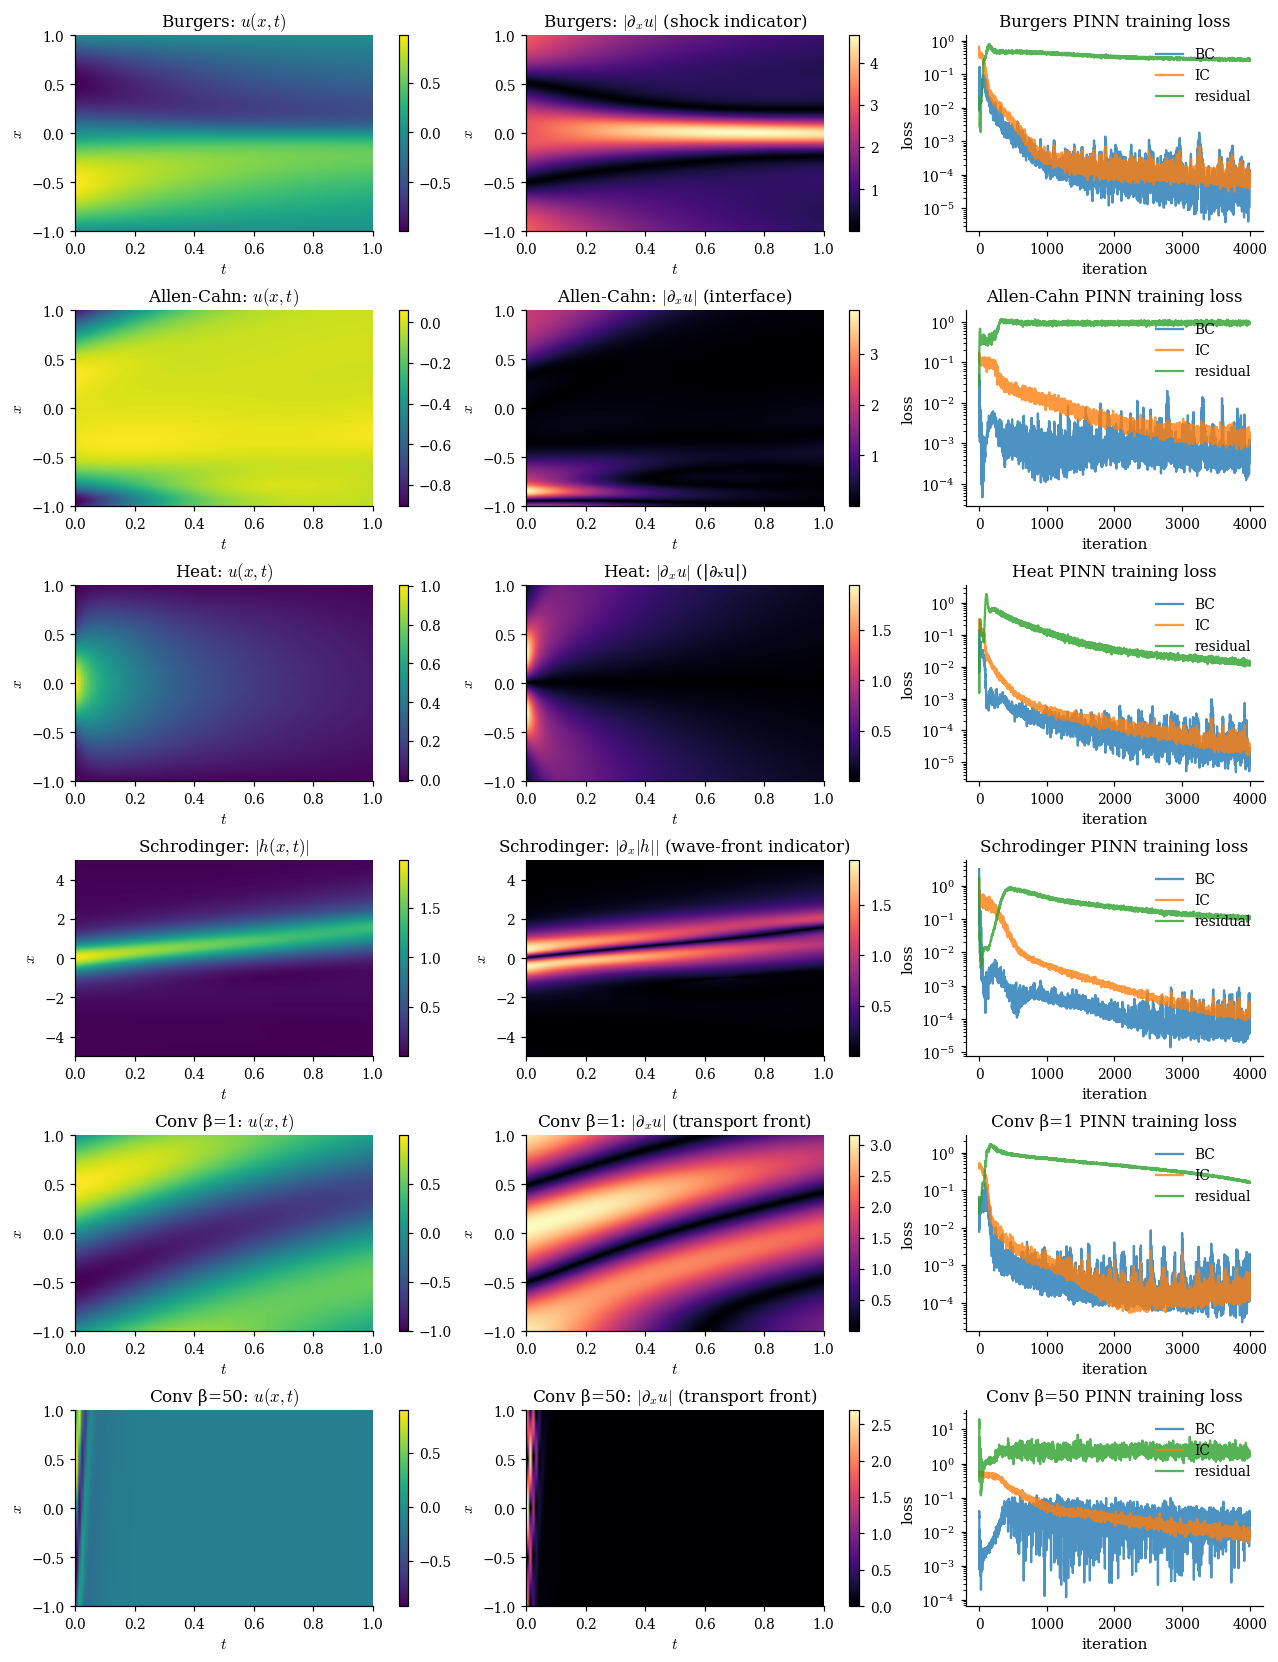

In [ ]:
xs_np = xs.numpy().squeeze(); ts_np = ts.numpy().squeeze()
extent = [ts_np.min(), ts_np.max(), xs_np.min(), xs_np.max()]

fig, axes = plt.subplots(6, 3, figsize=(11.5, 15.0),constrained_layout=True)
for row, (U, hist, label) in enumerate([(U_b, hist_b, "Burgers"),(U_a, hist_a, "Allen-Cahn"),(U_h, hist_h, "Heat"),(AMP_s_fig, hist_s, "Schrodinger"),(U_c1,  conv_hists[1],"Conv β=1"),(U_c50, conv_hists[50],"Conv β=50")]):
    if label == "Schrodinger":
      current_extent = [0, 1, -5, 5]
    else:
      current_extent = extent
    ax = axes[row,0]
    vmax = np.max(np.abs(U))
    im = ax.imshow(U,extent=current_extent,origin="lower",aspect="auto",cmap="viridis")
    if label == "Schrodinger":
      ax.set_title(f"{label}: $|h(x,t)|$")
    else:
      ax.set_title(f"{label}: $u(x,t)$")
    ax.set_xlabel("$t$"); ax.set_ylabel("$x$")
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax = axes[row,1]
    if label == "Schrodinger":
      ux = UX_s_fig
    else:
      ux = np.abs(np.gradient(U,xs_np[1]-xs_np[0],axis=0))
    im = ax.imshow(ux, extent=current_extent, origin="lower", aspect="auto", cmap="magma")
    if label == "Burgers":
       structure = "shock indicator"
    elif label == "Allen-Cahn":
       structure = "interface"

    elif label == "Heat":
       structure = "|∂ₓu|"

    elif label.startswith("Conv"):
      structure = "transport front"

    else:
       structure = "wave-front indicator"

    if label == "Schrodinger":
      ax.set_title(
        f"{label}: $|\\partial_x |h||$ ({structure})"
    )
    else:
      ax.set_title(
        f"{label}: $|\\partial_x u|$ ({structure})"
    )

    ax.set_xlabel("$t$")
    ax.set_ylabel("$x$")
    ax.set_xlabel("$t$"); ax.set_ylabel("$x$")
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax = axes[row,2]
    for j, lab in enumerate(["BC", "IC", "residual"]):
        ax.semilogy(hist[:,j], label=lab, alpha=0.8)
    ax.set_title(f"{label} PINN training loss"); ax.set_xlabel("iteration"); ax.set_ylabel("loss")
    ax.legend(frameon=False, loc="upper right")
plt.savefig("figures/fig1_pinn_solutions.png", bbox_inches="tight"); plt.show()

# 5. The sparse autoencoder



In [ ]:
class SparseAutoencoder(nn.Module):
    def __init__(self, d_in=HIDDEN, d_dict=DICT):
        super().__init__()
        self.enc = nn.Linear(d_in, d_dict, bias=True)
        self.dec = nn.Linear(d_dict, d_in, bias=True)
        with torch.no_grad():
            self.dec.weight.copy_(self.dec.weight / (self.dec.weight.norm(dim=0, keepdim=True) + 1e-8))
        self.b_pre = nn.Parameter(torch.zeros(d_in))
    def encode(self, h): return torch.relu(self.enc(h - self.b_pre))
    def decode(self, z): return self.dec(z) + self.b_pre
    def forward(self, h):
        z = self.encode(h); return self.decode(z), z

def train_sae(H, n_epochs=SAE_EPOCHS, batch=4096, lr=1e-3, lam=LAM_L1, verbose=True):
    H_t = torch.from_numpy(H).float()
    N, d_in = H_t.shape
    sae = SparseAutoencoder(d_in=d_in, d_dict=DICT)
    opt = torch.optim.Adam(sae.parameters(), lr=lr)
    losses = []
    for ep in range(n_epochs):
        perm = torch.randperm(N)
        sums = [0.,0.,0.,0.]; nb = 0
        for s in range(0, N, batch):
            idx = perm[s:s+batch]; h = H_t[idx]
            h_hat, z = sae(h)
            recon = ((h_hat - h)**2).sum(dim=1).mean()
            l1 = z.abs().sum(dim=1).mean()
            loss = recon + lam*l1
            opt.zero_grad(); loss.backward(); opt.step()
            with torch.no_grad():
                w = sae.dec.weight
                sae.dec.weight.copy_(w / (w.norm(dim=0, keepdim=True) + 1e-8))
            l0 = (z > 1e-6).float().sum(dim=1).mean().item()
            for j,v in enumerate([loss.item(), recon.item(), l1.item(), l0]): sums[j]+=v
            nb += 1
        sums = [s/nb for s in sums]; losses.append(sums)
        if verbose and (ep % 100 == 0 or ep == n_epochs-1):
            print(f"  ep {ep:4d} | recon {sums[1]:.3e} | L1 {sums[2]:.2f} | L0 {sums[3]:.2f}")
    return sae, np.array(losses)


### Activation normalization

We z-score the PINN activations across the grid before feeding them to the SAE — a small but important detail. Without it the L1 penalty interacts asymmetrically with neurons of different magnitudes and decoder unit-norm becomes meaningless.

In [ ]:
def normalize(H_flat):
    mu = H_flat.mean(0, keepdims=True)
    sd = H_flat.std(0, keepdims=True) + 1e-6
    return (H_flat - mu)/sd, mu, sd

H_b_flat = H_b.reshape(-1, HIDDEN)
H_a_flat = H_a.reshape(-1, HIDDEN)
H_h_flat = H_h.reshape(-1, HIDDEN)
H_s_flat = H_s.reshape(-1, HIDDEN)
H_c1_flat  = H_c1.reshape(-1, HIDDEN)
H_c50_flat = H_c50.reshape(-1, HIDDEN)

H_b_n, mu_b, sd_b = normalize(H_b_flat)
H_a_n, mu_a, sd_a = normalize(H_a_flat)
H_h_n, mu_h, sd_h = normalize(H_h_flat)
H_s_n, mu_s, sd_s = normalize(H_s_flat)
H_c1_n,  mu_c1,  sd_c1  = normalize(H_c1_flat)
H_c50_n, mu_c50, sd_c50 = normalize(H_c50_flat)

np.save("artifacts/burgers_H_norm_mean.npy", mu_b)
np.save("artifacts/burgers_H_norm_std.npy", sd_b)
np.save("artifacts/allencahn_H_norm_mean.npy", mu_a)
np.save("artifacts/allencahn_H_norm_std.npy", sd_a)
np.save("artifacts/heat_H_norm_mean.npy", mu_h)
np.save("artifacts/heat_H_norm_std.npy", sd_h)
np.save("artifacts/schrodinger_H_norm_mean.npy", mu_s)
np.save("artifacts/schrodinger_H_norm_std.npy", sd_s)
np.save("artifacts/convection_beta1_H_norm_mean.npy", mu_c1)
np.save("artifacts/convection_beta1_H_norm_std.npy",  sd_c1)
np.save("artifacts/convection_beta50_H_norm_mean.npy", mu_c50)
np.save("artifacts/convection_beta50_H_norm_std.npy",  sd_c50)
print(f"Burgers   activations: {H_b_n.shape}, mean(|h|)={np.abs(H_b_n).mean():.3f}")
print(f"AllenCahn activations: {H_a_n.shape}, mean(|h|)={np.abs(H_a_n).mean():.3f}")
print(f"Heat activations: {H_h_n.shape}, mean(|h|)={np.abs(H_h_n).mean():.3f}")
print(f"Schrodinger activations: "f"{H_s_n.shape}, "f"mean(|h|)={np.abs(H_s_n).mean():.3f}")
print(f"Conv β=1 activations: "f"{H_c1_n.shape}, "f"mean(|h|)={np.abs(H_c1_n).mean():.3f}")
print(f"Conv β=50 activations: "f"{H_c50_n.shape}, "f"mean(|h|)={np.abs(H_c50_n).mean():.3f}")

Burgers   activations: (25600, 40), mean(|h|)=0.838
AllenCahn activations: (25600, 40), mean(|h|)=0.800
Heat activations: (25600, 40), mean(|h|)=0.730
Schrodinger activations: (25600, 40), mean(|h|)=0.827
Conv β=1 activations: (25600, 40), mean(|h|)=0.818
Conv β=50 activations: (25600, 40), mean(|h|)=0.340


### Train the all SAEs (~1 min each)

In [ ]:
def get_sae(tag, H_norm):
    pt = f"artifacts/{tag}_sae.pt"
    if os.path.exists(pt):
        sae = SparseAutoencoder(); sae.load_state_dict(torch.load(pt))
        hist = np.load(f"artifacts/{tag}_sae_hist.npy")
        print(f"Loaded cached SAE for {tag}.")
        return sae, hist
    print(f"Training SAE for {tag}...")
    sae, hist = train_sae(H_norm)
    torch.save(sae.state_dict(), pt)
    np.save(f"artifacts/{tag}_sae_hist.npy", hist)
    return sae, hist

sae_b, sae_hist_b = get_sae("burgers", H_b_n)
sae_a, sae_hist_a = get_sae("allencahn", H_a_n)
sae_h, sae_hist_h = get_sae("heat", H_h_n)
sae_s, sae_hist_s = get_sae("schrodinger",H_s_n)
sae_c1,  sae_hist_c1  = get_sae("convection_beta1",H_c1_n)
sae_c50, sae_hist_c50 = get_sae("convection_beta50",H_c50_n)

with torch.no_grad():
    Z_b = sae_b.encode(torch.from_numpy(H_b_n).float()).numpy().reshape(nx, nt, DICT)
    Z_a = sae_a.encode(torch.from_numpy(H_a_n).float()).numpy().reshape(nx, nt, DICT)
    Z_h = sae_h.encode(torch.from_numpy(H_h_n).float()).numpy().reshape(nx, nt, DICT)
    Z_s = sae_s.encode(torch.from_numpy(H_s_n).float()).numpy().reshape(nx, nt, DICT)
    Z_c1 = sae_c1.encode(torch.from_numpy(H_c1_n).float()).numpy().reshape(nx, nt, DICT)
    Z_c50 = sae_c50.encode(torch.from_numpy(H_c50_n).float()).numpy().reshape(nx, nt, DICT)
np.save("artifacts/burgers_Z.npy", Z_b)
np.save("artifacts/allencahn_Z.npy", Z_a)
np.save("artifacts/heat_Z.npy", Z_h)
np.save("artifacts/schrodinger_Z.npy",Z_s)
np.save("artifacts/convection_beta1_Z.npy",Z_c1)
np.save("artifacts/convection_beta50_Z.npy",Z_c50)

print(f"Burgers   final L0 = {sae_hist_b[-1,3]:.1f} / {DICT}, recon = {sae_hist_b[-1,1]:.2e}")
print(f"AllenCahn final L0 = {sae_hist_a[-1,3]:.1f} / {DICT}, recon = {sae_hist_a[-1,1]:.2e}")
print(f"Heat finel L0 = {sae_hist_h[-1,3]:.1f} / {DICT}, recon = {sae_hist_h[-1,1]:.2e}")
print(f"Schrodinger final L0 = "f"{sae_hist_s[-1,3]:.1f}/{DICT}, "f"recon = {sae_hist_s[-1,1]:.2e}")
print(f"Conv β=1 final L0 = "f"{sae_hist_c1[-1,3]:.1f}/{DICT}, "f"recon = {sae_hist_c1[-1,1]:.2e}")
print(f"Conv β=50 final L0 = "f"{sae_hist_c50[-1,3]:.1f}/{DICT}, "f"recon = {sae_hist_c50[-1,1]:.2e}")

Training SAE for burgers...
  ep    0 | recon 4.569e+01 | L1 27.93 | L0 64.22
  ep  100 | recon 6.060e-02 | L1 14.26 | L0 44.02
  ep  200 | recon 3.135e-02 | L1 9.66 | L0 30.58
  ep  300 | recon 2.242e-02 | L1 8.43 | L0 23.50
  ep  400 | recon 1.820e-02 | L1 7.97 | L0 20.77
  ep  499 | recon 1.524e-02 | L1 7.67 | L0 19.23
Training SAE for allencahn...
  ep    0 | recon 4.890e+01 | L1 29.67 | L0 64.38
  ep  100 | recon 6.467e-02 | L1 15.05 | L0 46.57
  ep  200 | recon 3.415e-02 | L1 10.04 | L0 31.51
  ep  300 | recon 2.411e-02 | L1 8.60 | L0 24.39
  ep  400 | recon 1.920e-02 | L1 8.05 | L0 21.20
  ep  499 | recon 1.594e-02 | L1 7.69 | L0 18.96
Training SAE for heat...
  ep    0 | recon 5.615e+01 | L1 25.47 | L0 61.72
  ep  100 | recon 6.567e-02 | L1 13.48 | L0 43.00
  ep  200 | recon 3.563e-02 | L1 9.16 | L0 28.56
  ep  300 | recon 2.465e-02 | L1 7.82 | L0 22.61
  ep  400 | recon 1.890e-02 | L1 7.16 | L0 19.27
  ep  499 | recon 1.528e-02 | L1 6.77 | L0 16.82
Training SAE for schrodinger

# 6. Defining the ground-truth concept fields



In [ ]:
def concepts_burgers(U, xs, ts):
    dx = xs[1]-xs[0]; dt = ts[1]-ts[0]
    u_x = np.gradient(U, dx, axis=0); u_t = np.gradient(U, dt, axis=1)
    u_xx = np.gradient(u_x, dx, axis=0)
    nx, nt = U.shape
    return {
        "|u|": np.abs(U),
        "|u_x| (shock)": np.abs(u_x),
        "|u_t|": np.abs(u_t),
        "u (signed)": U,
        "|u_xx| (curvature)": np.abs(u_xx),
        "dist to x=0": np.tile(np.abs(xs).reshape(-1,1), (1, nt)),
        "t (time)": np.tile(ts.reshape(1,-1), (nx, 1)),
    }

def concepts_allencahn(U, xs, ts):
    dx = xs[1]-xs[0]; dt = ts[1]-ts[0]
    u_x = np.gradient(U, dx, axis=0); u_t = np.gradient(U, dt, axis=1)
    nx, nt = U.shape
    return {
        "|u|": np.abs(U),
        "|u_x| (interface)": np.abs(u_x),
        "|u_t|": np.abs(u_t),
        "u (signed)": U,
        "u^3 (reaction)": U**3,
        "interface (exp(-u^2/0.1))": np.exp(-U**2/0.1),
        "t (time)": np.tile(ts.reshape(1,-1), (nx, 1)),
    }
def concepts_heat(U, xs, ts):
    dx = xs[1] - xs[0]
    dt = ts[1] - ts[0]
    u_x = np.gradient(U, dx, axis=0)
    u_t = np.gradient(U, dt, axis=1)
    u_xx = np.gradient(u_x, dx, axis=0)
    nx, nt = U.shape
    return {
        "|u|": np.abs(U),
        "|u_x| (gradient)": np.abs(u_x),
        "|u_t|": np.abs(u_t),
        "|u_xx| (curvature)": np.abs(u_xx),
        "t (time)": np.tile(ts.reshape(1,-1),(nx,1))
    }
def concepts_schrodinger(U, V, AMP, PHI, xs, ts):
    dx = xs[1] - xs[0]
    dt = ts[1] - ts[0]
    u_x = np.gradient(U, dx, axis=0)
    v_x = np.gradient(V, dx, axis=0)
    u_t = np.gradient(U, dt, axis=1)
    v_t = np.gradient(V, dt, axis=1)
    h_x = np.sqrt(u_x**2 + v_x**2)
    h_t = np.sqrt(u_t**2 + v_t**2)
    nx, nt = U.shape
    return {
        "|h| (amplitude)" : AMP,
        "u (real)" : U,
        "v (imag)" : V,
        "|h_x| (wave-front)" : h_x,
        "|h_t| (temporal)" : h_t,
        "phi (phase)" : PHI,
        "t (time)" : np.tile(ts.reshape(1,-1),(nx,1))
    }

def concepts_convection(U, xs, ts, beta):
    dx = xs[1] - xs[0]
    dt = ts[1] - ts[0]
    u_x = np.gradient(U, dx, axis=0)
    u_t = np.gradient(U, dt, axis=1)
    nx, nt = U.shape
    X = np.tile(xs.reshape(-1,1), (1, nt))
    T = np.tile(ts.reshape(1,-1), (nx, 1))
    concepts = {
        "|u|" : np.abs(U),
        "|u_x| (transport front)" : np.abs(u_x),
        "|u_t|" : np.abs(u_t),
        "u (signed)" : U,
        "x position" : X,
        "t (time)" : T,
    }

    if beta == 1:
        concepts["characteristic (x-t)"] = X - T
    else:
        concepts[f"characteristic (x-{beta}t)"] = X - beta*T

    return concepts

# Convert grid to NumPy
xs_np = xs.numpy().squeeze()
ts_np = ts.numpy().squeeze()
#schrodinger
xs_s = np.linspace(-5, 5, U_s.shape[0])
ts_s = np.linspace(0, 1, U_s.shape[1])

C_b = concepts_burgers(U_b, xs_np, ts_np)
C_a = concepts_allencahn(U_a, xs_np, ts_np)
C_h = concepts_heat(U_h, xs_np, ts_np)
C_s = concepts_schrodinger(U_s,V_s,AMP_s,PHI_s,np.linspace(-5,5,U_s.shape[0]),np.linspace(0,1,U_s.shape[1]))
C_c1 = concepts_convection(U_c1,xs_np,ts_np, beta=1)
C_c50 = concepts_convection(U_c50,xs_np,ts_np, beta=50)

np.savez("artifacts/burgers_concepts.npz", **C_b)
np.savez("artifacts/allencahn_concepts.npz", **C_a)
np.savez("artifacts/heat_concepts.npz",**C_h)
np.savez("artifacts/schrodinger_concepts.npz",**C_s)
np.savez("artifacts/convection_beta1_concepts.npz",**C_c1)
np.savez("artifacts/convection_beta50_concepts.npz",**C_c50)

print("Burgers concepts  :", list(C_b.keys()))
print("AllenCahn concepts:", list(C_a.keys()))
print("Heat concepts     :", list(C_h.keys()))
print("Schrodinger concepts:",list(C_s.keys()))
print("Conv β=1 concepts:",list(C_c1.keys()))
print("Conv β=50 concepts:",list(C_c50.keys()))

Burgers concepts  : ['|u|', '|u_x| (shock)', '|u_t|', 'u (signed)', '|u_xx| (curvature)', 'dist to x=0', 't (time)']
AllenCahn concepts: ['|u|', '|u_x| (interface)', '|u_t|', 'u (signed)', 'u^3 (reaction)', 'interface (exp(-u^2/0.1))', 't (time)']
Heat concepts     : ['|u|', '|u_x| (gradient)', '|u_t|', '|u_xx| (curvature)', 't (time)']
Schrodinger concepts: ['|h| (amplitude)', 'u (real)', 'v (imag)', '|h_x| (wave-front)', '|h_t| (temporal)', 'phi (phase)', 't (time)']
Conv β=1 concepts: ['|u|', '|u_x| (transport front)', '|u_t|', 'u (signed)', 'x position', 't (time)', 'characteristic (x-t)']
Conv β=50 concepts: ['|u|', '|u_x| (transport front)', '|u_t|', 'u (signed)', 'x position', 't (time)', 'characteristic (x-50t)']


# 7. Atom–concept alignment matrix



In [ ]:
def alignment(Z_field, concepts):
    K = Z_field.shape[-1]
    names = list(concepts.keys())
    A = np.zeros((K, len(names)))

    for k in range(K):
        zk = Z_field[..., k].flatten()

        if zk.std() < 1e-8:
            continue

        zk = (zk - zk.mean()) / (zk.std() + 1e-12)

        for j, name in enumerate(names):
            c = concepts[name].flatten()

            if c.std() < 1e-8:
                continue

            c = (c - c.mean()) / (c.std() + 1e-12)

            A[k, j] = (zk * c).mean()

    return A, names

A_b, names_b = alignment(Z_b, C_b)
A_a, names_a = alignment(Z_a, C_a)
A_h, names_h = alignment(Z_h, C_h)
A_s, names_s = alignment(Z_s, C_s)
A_c1, names_c1 = alignment(Z_c1,C_c1)
A_c50, names_c50 = alignment(Z_c50,C_c50)

np.save("artifacts/burgers_alignment.npy", A_b)
np.save("artifacts/allencahn_alignment.npy", A_a)
np.save("artifacts/heat_alignment.npy", A_h)
np.save("artifacts/schrodinger_alignment.npy",A_s)
np.save("artifacts/convection_beta1_alignment.npy",A_c1)
np.save("artifacts/convection_beta50_alignment.npy",A_c50)

# PCA baseline
pca_b = PCA(n_components=min(HIDDEN,16)).fit(H_b_n)
pca_a = PCA(n_components=min(HIDDEN,16)).fit(H_a_n)
pca_h = PCA(n_components=min(HIDDEN,16)).fit(H_h_n)
pca_s = PCA(n_components=min(HIDDEN,16)).fit(H_s_n)
pca_c1 = PCA(n_components=min(HIDDEN,16)).fit(H_c1_n)
pca_c50 = PCA(n_components=min(HIDDEN,16)).fit(H_c50_n)

P_b = pca_b.transform(H_b_n).reshape(nx, nt, -1)
P_a = pca_a.transform(H_a_n).reshape(nx, nt, -1)
P_h = pca_h.transform(H_h_n).reshape(nx, nt, -1)
P_s = pca_s.transform(H_s_n).reshape(nx, nt, -1)
P_c1 = pca_c1.transform(H_c1_n).reshape(nx,nt,-1)
P_c50 = pca_c50.transform(H_c50_n).reshape(nx,nt,-1)
A_pca_b, _ = alignment(P_b, C_b)
A_pca_a, _ = alignment(P_a, C_a)
A_pca_h, _ = alignment(P_h, C_h)
A_pca_s, _ = alignment(P_s, C_s)
A_pca_c1, _ = alignment(P_c1,C_c1)
A_pca_c50, _ = alignment(P_c50,C_c50)
np.save("artifacts/burgers_pca_alignment.npy", A_pca_b)
np.save("artifacts/allencahn_pca_alignment.npy", A_pca_a)
np.save("artifacts/heat_pca_alignment.npy", A_pca_h)
np.save("artifacts/schrodinger_pca_alignment.npy",A_pca_s)
np.save("artifacts/convection_beta1_pca_alignment.npy",A_pca_c1)
np.save("artifacts/convection_beta50_pca_alignment.npy",A_pca_c50)
print("Alignment done.")


Alignment done.


### Top atom per concept (SAE) vs best PC (PCA)

In [ ]:
def print_table(A, A_pca, names, label):
    print(f"\n{label}:")
    print(f"{'concept':30s} | {'top atom':>9s} | {'SAE r':>7s} | {'best PC':>8s} | {'PCA r':>7s}")
    print("-"*70)
    for j, name in enumerate(names):
        k_sae = int(np.argmax(np.abs(A[:, j])))
        k_pca = int(np.argmax(np.abs(A_pca[:, j])))
        print(f"{name:30s} | atom {k_sae:3d}  | {A[k_sae,j]:+.3f} | PC{k_pca+1:2d}     | {A_pca[k_pca,j]:+.3f}")
print_table(A_b, A_pca_b, names_b, "Burgers")
print_table(A_a, A_pca_a, names_a, "Allen-Cahn")
print_table(A_h, A_pca_h, names_h, "Heat")
print_table(A_s,A_pca_s,names_s,"Schrodinger")
print_table(A_c1,A_pca_c1,names_c1,"Convection β=1")
print_table(A_c50,A_pca_c50,names_c50,"Convection β=50")


Burgers:
concept                        |  top atom |   SAE r |  best PC |   PCA r
----------------------------------------------------------------------
|u|                            | atom  96  | -0.470 | PC 2     | +0.473
|u_x| (shock)                  | atom  21  | +0.694 | PC 9     | +0.412
|u_t|                          | atom  32  | +0.592 | PC 3     | -0.526
u (signed)                     | atom  99  | +0.747 | PC 1     | +0.656
|u_xx| (curvature)             | atom  50  | +0.739 | PC 2     | +0.553
dist to x=0                    | atom 104  | -0.658 | PC 2     | -0.894
t (time)                       | atom  89  | +0.592 | PC 3     | +0.922

Allen-Cahn:
concept                        |  top atom |   SAE r |  best PC |   PCA r
----------------------------------------------------------------------
|u|                            | atom  63  | +0.928 | PC 2     | +0.662
|u_x| (interface)              | atom  63  | +0.840 | PC 2     | +0.672
|u_t|                          | atom  

### Figure 2 — Alignment matrices, SAE vs PCA

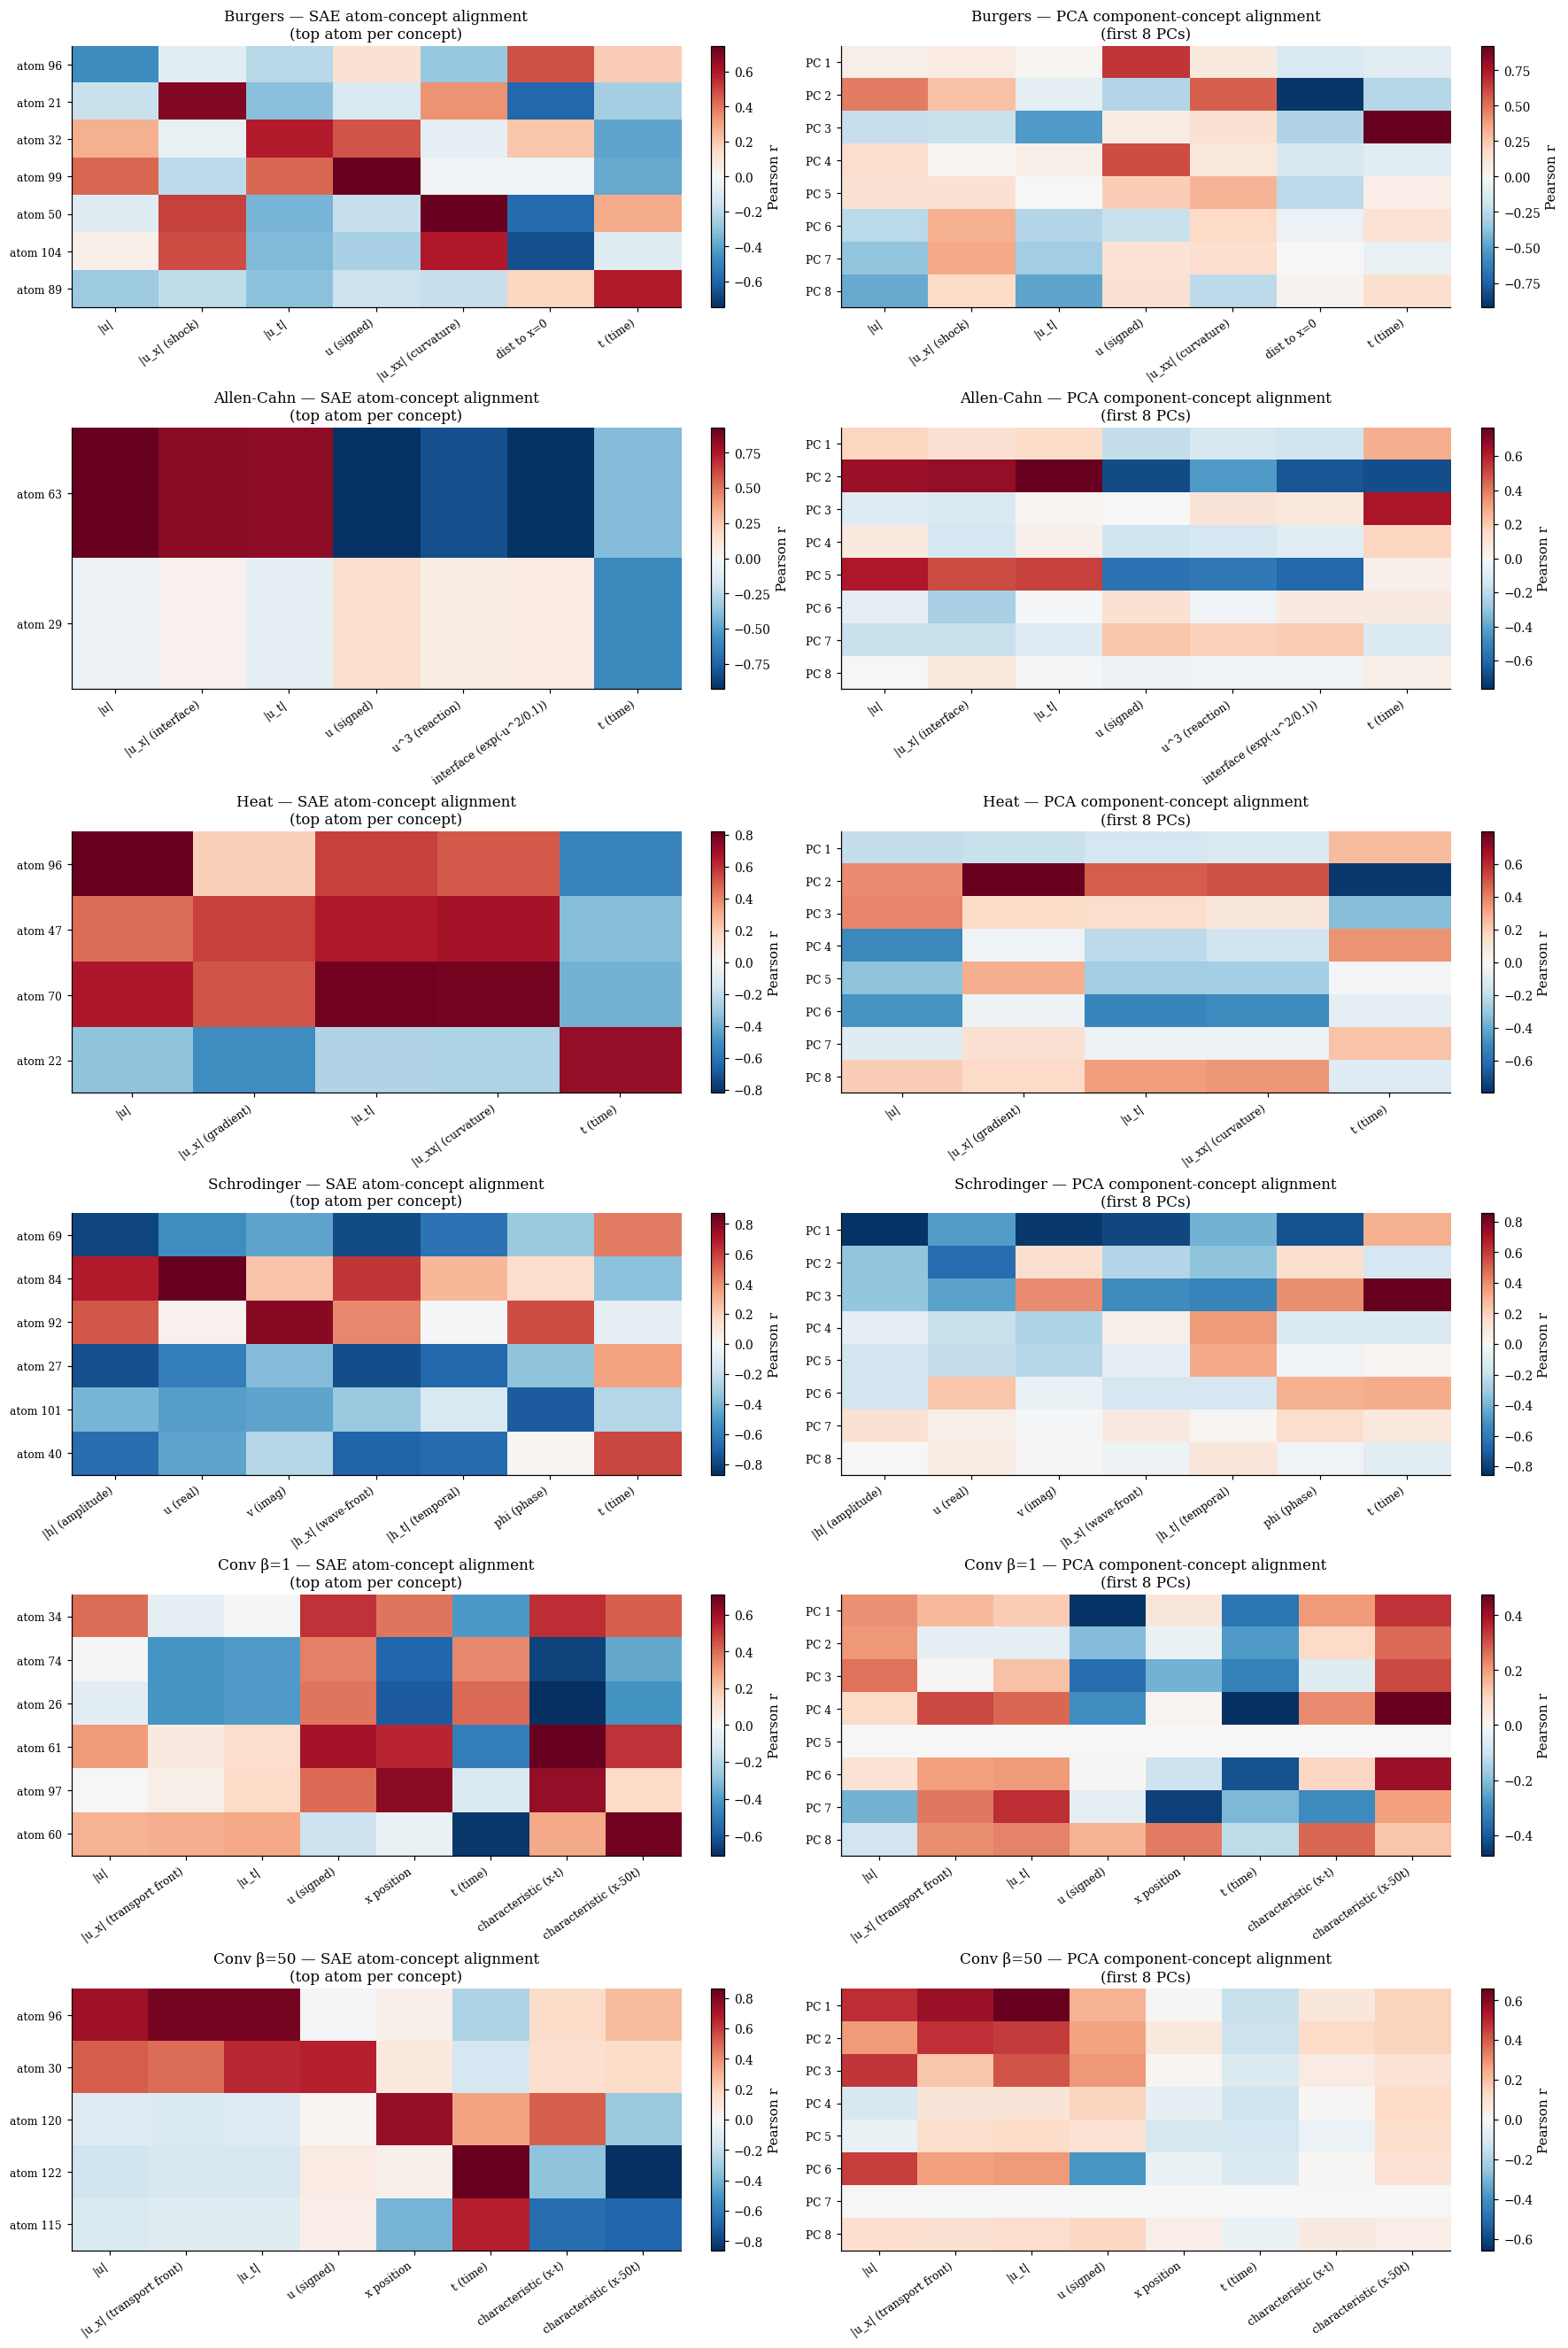

In [ ]:
def fig2(A_dict, A_pca_dict, names_dict):
    fig, axes = plt.subplots(6, 2, figsize=(16, 24), constrained_layout=True)
    for row, tag in enumerate(["Burgers", "Allen-Cahn","Heat","Schrodinger","Conv β=1","Conv β=50"]):
        A, A_pca, names = A_dict[tag], A_pca_dict[tag], names_dict[tag]
        rows = [int(np.argmax(np.abs(A[:, j]))) for j in range(A.shape[1])]
        rows_u = list(dict.fromkeys(rows))
        A_show = A[rows_u]
        ax = axes[row, 0]
        vmax = max(np.abs(A_show).max(), 1e-3)
        im = ax.imshow(A_show, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
        ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=35, ha="right", fontsize=8)
        ax.set_yticks(range(len(rows_u))); ax.set_yticklabels([f"atom {k}" for k in rows_u], fontsize=8)
        ax.set_title(f"{tag} — SAE atom-concept alignment\n(top atom per concept)")
        plt.colorbar(im, ax=ax, fraction=0.04, label="Pearson r")
        K_pca = min(8, A_pca.shape[0])
        ax = axes[row, 1]
        vmax = max(np.abs(A_pca[:K_pca]).max(), 1e-3)
        im = ax.imshow(A_pca[:K_pca], cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
        ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=35, ha="right", fontsize=8)
        ax.set_yticks(range(K_pca)); ax.set_yticklabels([f"PC {k+1}" for k in range(K_pca)], fontsize=8)
        ax.set_title(f"{tag} — PCA component-concept alignment\n(first {K_pca} PCs)")
        plt.colorbar(im, ax=ax, fraction=0.04, label="Pearson r")
    plt.savefig("figures/fig2_alignment.png", bbox_inches="tight"); plt.show()

fig2({"Burgers":A_b,"Allen-Cahn":A_a,"Heat":A_h,"Schrodinger":A_s,"Conv β=1":A_c1,"Conv β=50":A_c50},
    {"Burgers":A_pca_b,"Allen-Cahn":A_pca_a,"Heat":A_pca_h,"Schrodinger":A_pca_s,"Conv β=1":A_c1,"Conv β=50":A_c50},
    {"Burgers":names_b,"Allen-Cahn":names_a,"Heat":names_h,"Schrodinger":names_s,"Conv β=1":names_c1,"Conv β=50":names_c50})


##  Spatial structure of the top atoms


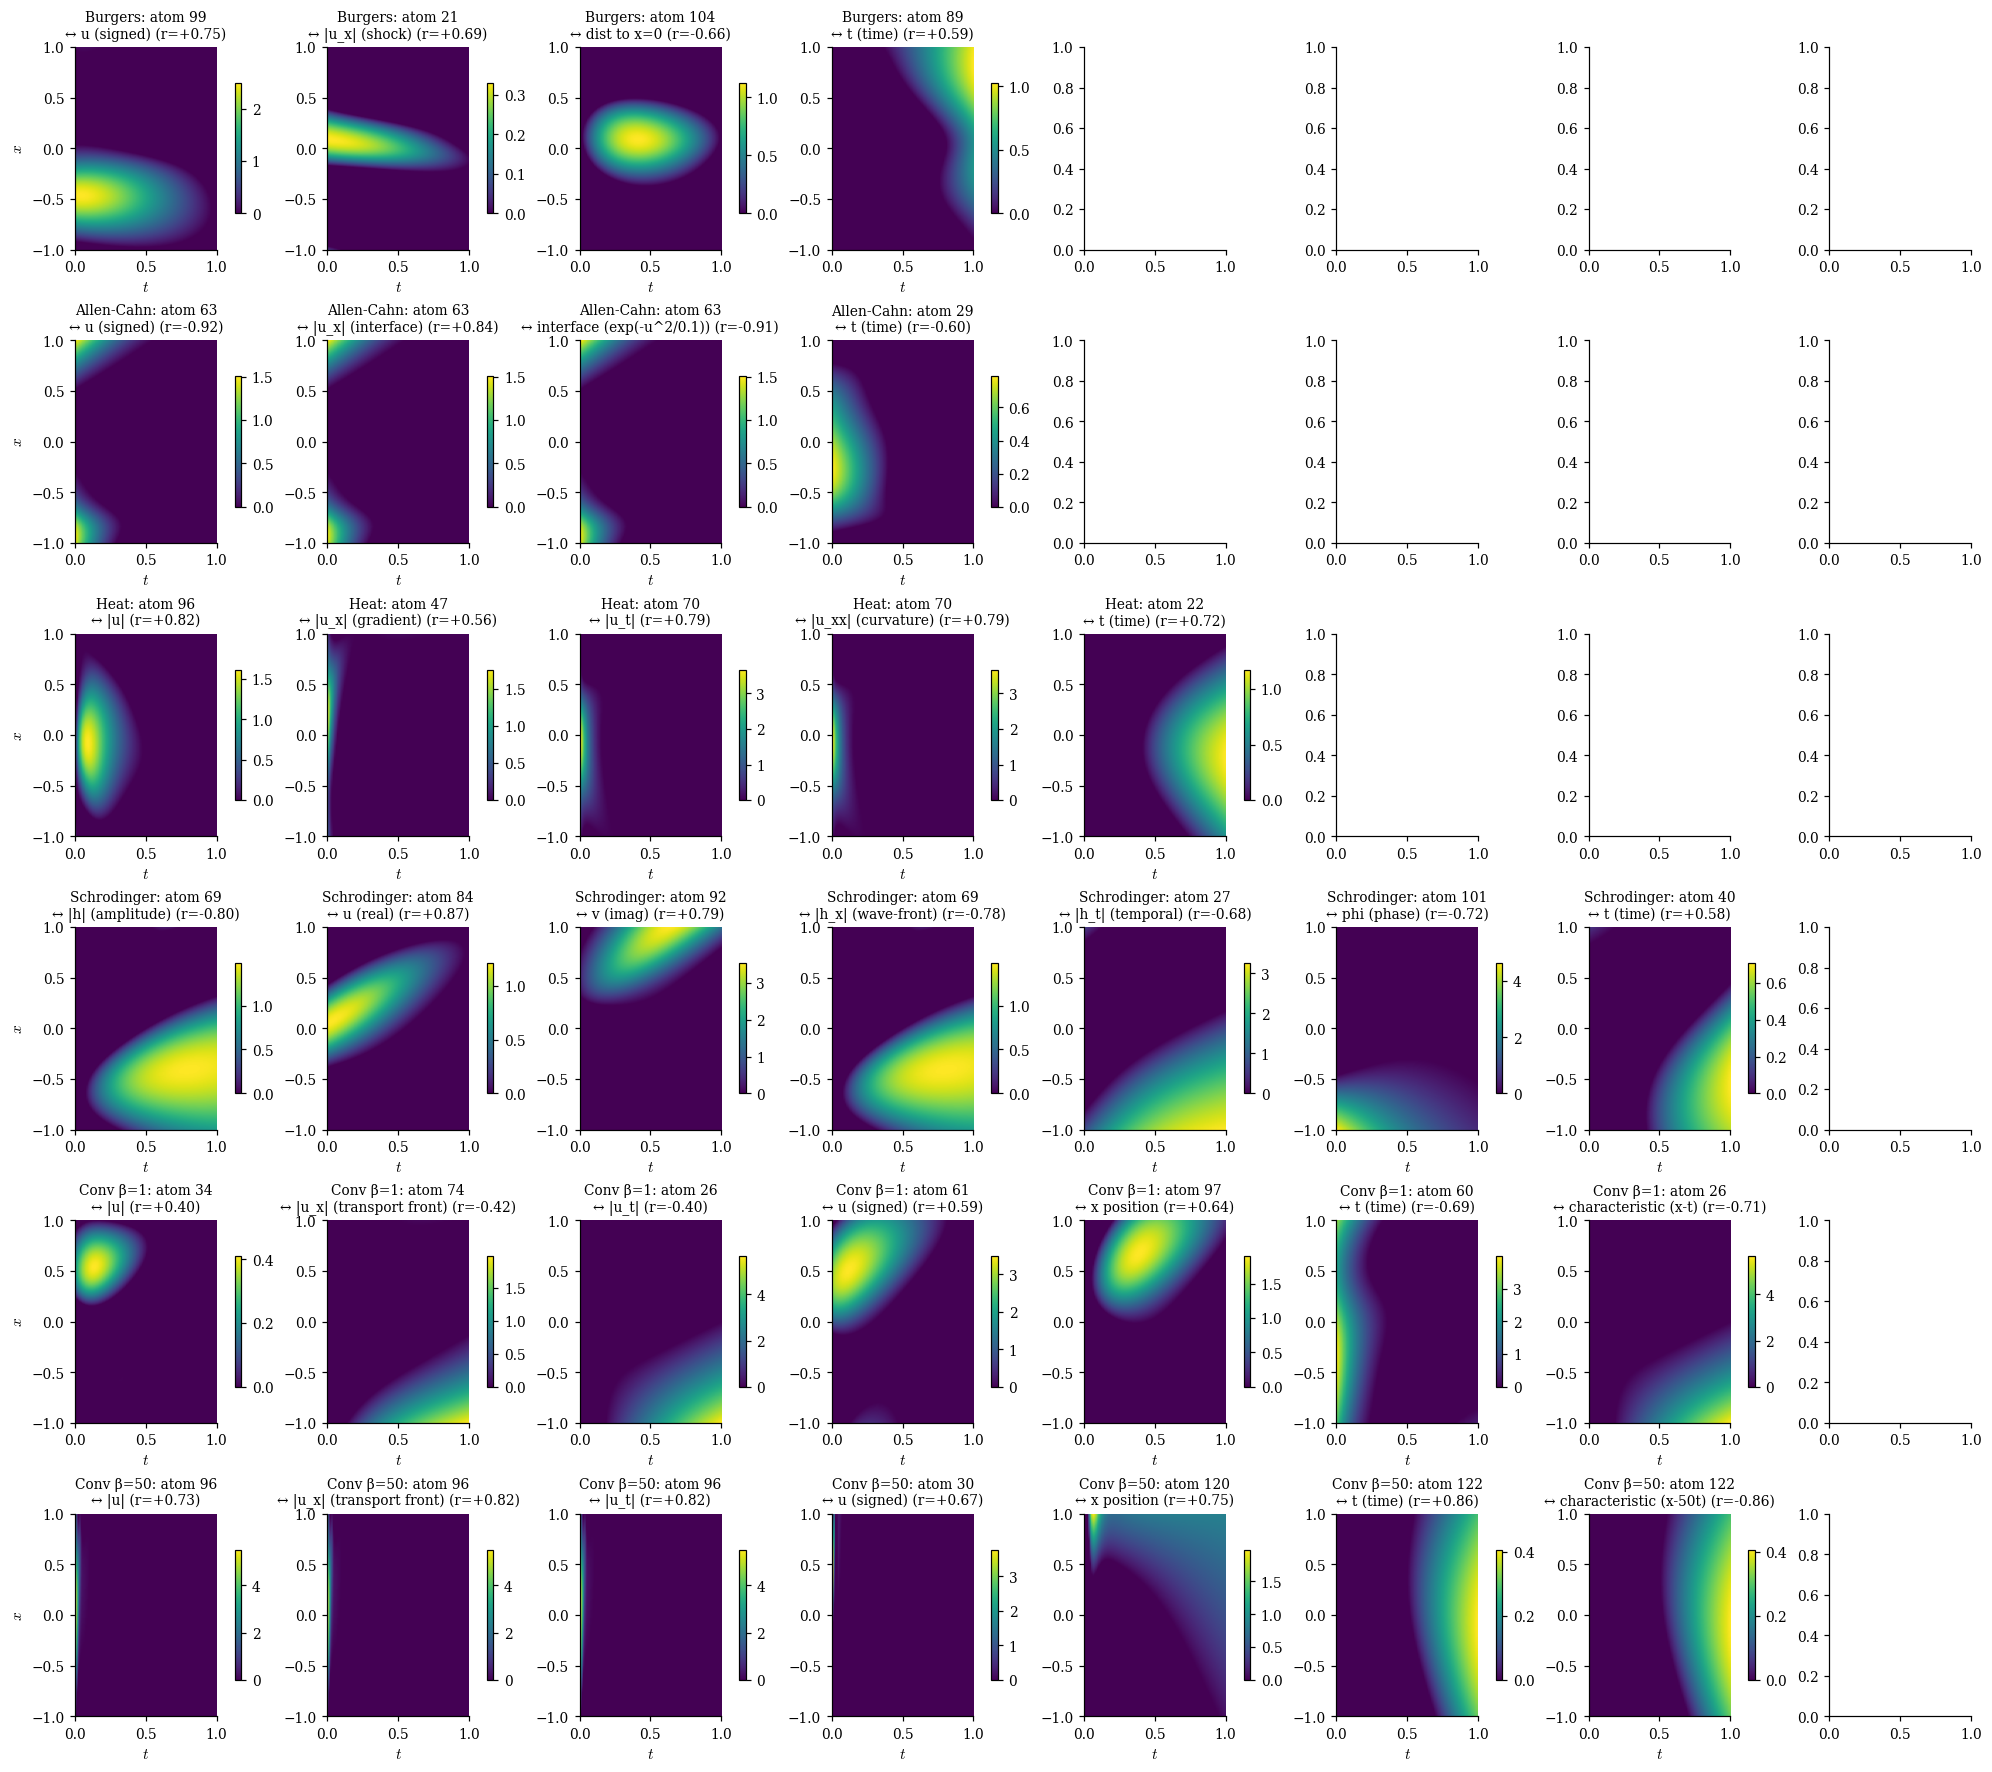

In [ ]:
def fig3(d_list):
    fig, axes = plt.subplots(6, 8, figsize=(18, 16), constrained_layout=True)
    for row, (Z, A, names, concept_subset, tag) in enumerate(d_list):
        for j_idx, cname in enumerate(concept_subset):
            j = names.index(cname)
            k_top = int(np.argmax(np.abs(A[:, j])))
            r = A[k_top, j]
            zk = Z[..., k_top]
            ax = axes[row, j_idx]
            vmax = zk.max()
            im = ax.imshow(zk, extent=extent, origin="lower", aspect="auto",
                           cmap="viridis", vmin=0, vmax=vmax if vmax>0 else 1)
            ax.set_title(f"{tag}: atom {k_top}\n↔ {cname} (r={r:+.2f})", fontsize=9)
            ax.set_xlabel("$t$")
            if j_idx == 0: ax.set_ylabel("$x$")
            plt.colorbar(im, ax=ax, fraction=0.046)
    plt.savefig("figures/fig3_atoms.png", bbox_inches="tight"); plt.show()

burgers_concepts_show = ["u (signed)", "|u_x| (shock)", "dist to x=0", "t (time)"]
ac_concepts_show      = ["u (signed)", "|u_x| (interface)", "interface (exp(-u^2/0.1))", "t (time)"]
heat_concepts_show = ["|u|","|u_x| (gradient)","|u_t|","|u_xx| (curvature)","t (time)"]
sch_concepts_show = ["|h| (amplitude)","u (real)","v (imag)","|h_x| (wave-front)","|h_t| (temporal)" ,"phi (phase)","t (time)"]
conv1_concepts_show = ["|u|","|u_x| (transport front)","|u_t|","u (signed)","x position","t (time)","characteristic (x-t)"]
conv50_concepts_show = ["|u|","|u_x| (transport front)","|u_t|","u (signed)","x position","t (time)","characteristic (x-50t)"]
fig3([(Z_b, A_b, names_b, burgers_concepts_show, "Burgers"),
      (Z_a, A_a, names_a, ac_concepts_show, "Allen-Cahn"),
      (Z_h, A_h, names_h,heat_concepts_show,"Heat"),
      (Z_s,A_s,names_s,sch_concepts_show,"Schrodinger"),
      (Z_c1,A_c1,names_c1,conv1_concepts_show,"Conv β=1"),
      (Z_c50,A_c50,names_c50,conv50_concepts_show,"Conv β=50")])

# 8. Ablation — closed-loop causal check - Figure 4



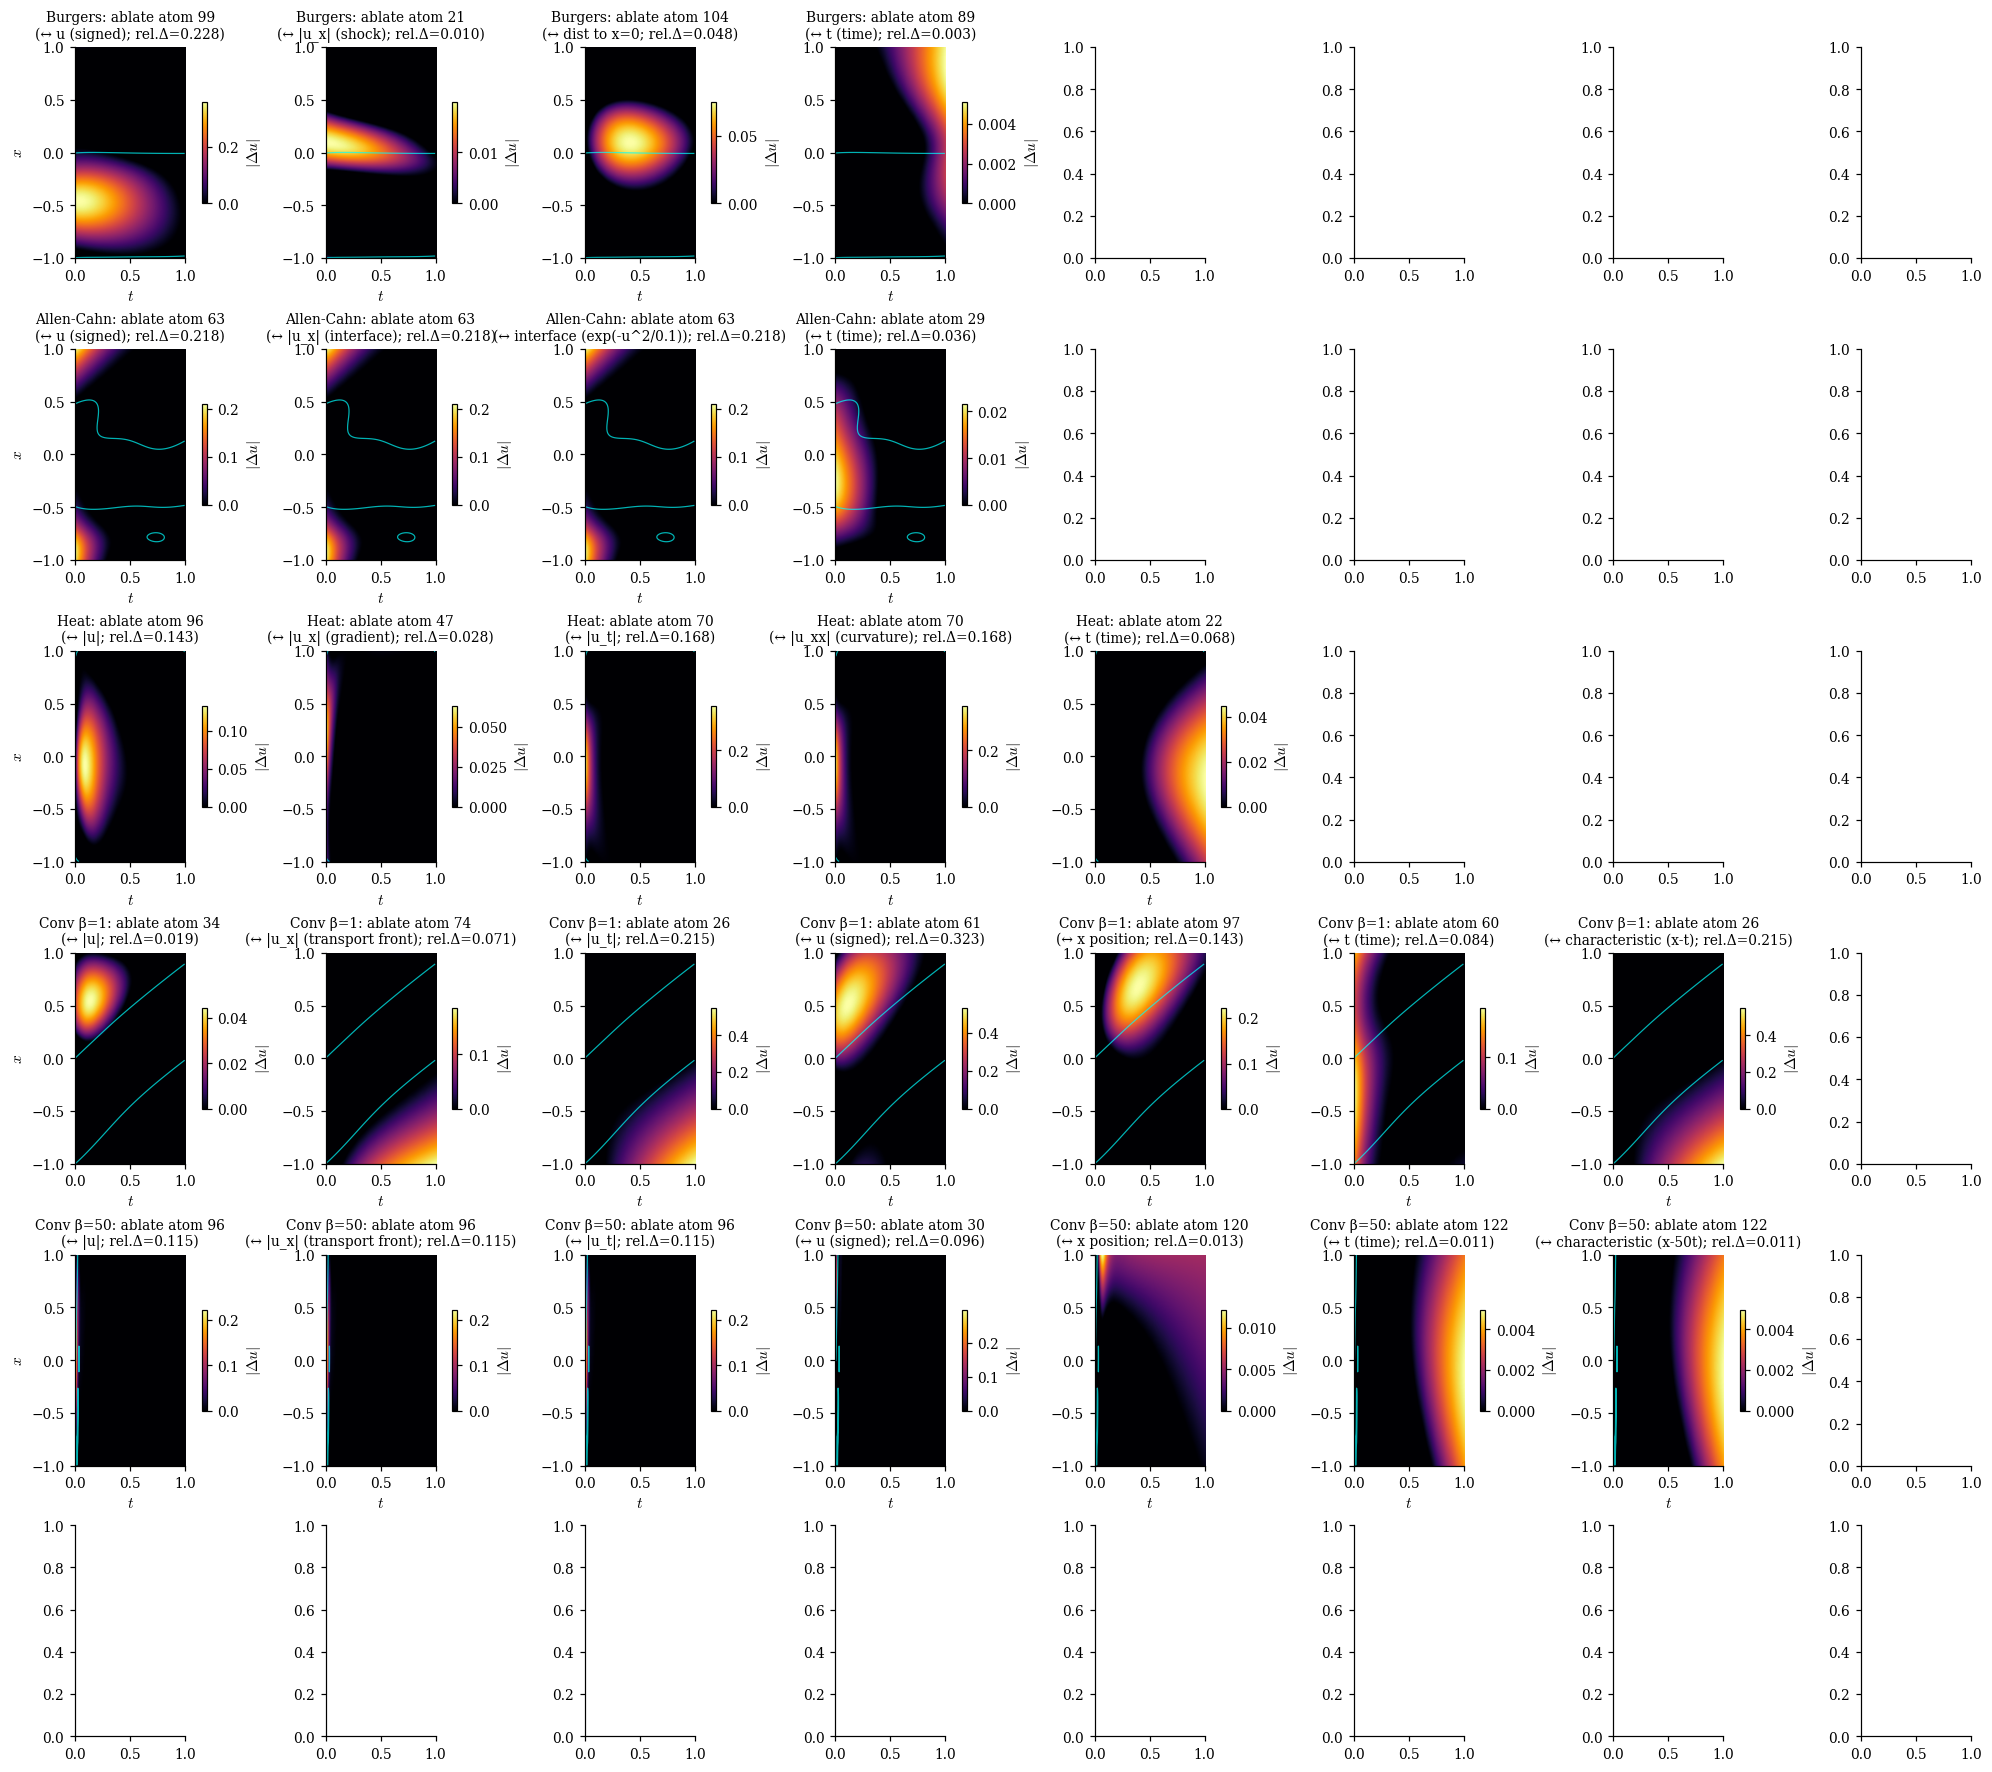

In [ ]:
def intervene_ablate(pinn, sae, H, mu, sd, atom_idx):
    H_flat = H.reshape(-1, HIDDEN)
    H_n = (H_flat - mu)/sd
    Ht = torch.from_numpy(H_n).float()
    with torch.no_grad():
        z = sae.encode(Ht)
        h_recon_n = sae.decode(z).numpy()
        z_mod = z.clone(); z_mod[:, atom_idx] = 0.0
        h_mod_n = sae.decode(z_mod).numpy()
    h_recon = h_recon_n * sd + mu
    h_mod   = h_mod_n   * sd + mu
    W = pinn.net[-1].weight.detach().numpy(); b = pinn.net[-1].bias.detach().numpy()
    u_recon = (h_recon @ W.T + b).reshape(nx, nt)
    u_mod   = (h_mod   @ W.T + b).reshape(nx, nt)
    return u_recon, u_mod, u_recon - u_mod

def fig4(items):
    fig, axes = plt.subplots(6, 8, figsize=(18, 16), constrained_layout=True)
    for row, (pinn, sae, H, mu, sd, A, names, U, concepts_to_show, tag) in enumerate(items):
        for j_idx, cname in enumerate(concepts_to_show):
            j = names.index(cname)
            k_top = int(np.argmax(np.abs(A[:, j])))
            u_recon, u_mod, delta = intervene_ablate(pinn, sae, H, mu, sd, k_top)
            ax = axes[row, j_idx]
            adelta = np.abs(delta); vmax = adelta.max()
            im = ax.imshow(adelta, extent=extent, origin="lower", aspect="auto",
                           cmap="inferno", vmin=0, vmax=vmax if vmax>0 else 1)
            ax.contour(U, levels=[0.0], extent=extent, origin="lower",
                       colors="cyan", linewidths=0.8, alpha=0.7)
            rel = np.linalg.norm(delta) / (np.linalg.norm(u_recon) + 1e-12)
            ax.set_title(f"{tag}: ablate atom {k_top}\n(↔ {cname}; rel.Δ={rel:.3f})", fontsize=9)
            ax.set_xlabel("$t$")
            if j_idx == 0: ax.set_ylabel("$x$")
            plt.colorbar(im, ax=ax, fraction=0.046, label=r"$|\Delta u|$")
    plt.savefig("figures/fig4_intervention.png", bbox_inches="tight"); plt.show()

fig4([
    (pinn_b, sae_b, H_b, mu_b, sd_b, A_b, names_b, U_b, burgers_concepts_show, "Burgers"),
    (pinn_a, sae_a, H_a, mu_a, sd_a, A_a, names_a, U_a, ac_concepts_show,      "Allen-Cahn"),
    (pinn_h,sae_h,H_h,mu_h,sd_h,A_h,names_h,U_h,heat_concepts_show,"Heat"),
    (conv_models[1], sae_c1, H_c1, mu_c1, sd_c1, A_c1, names_c1, U_c1,conv1_concepts_show, "Conv β=1"),
    (conv_models[50], sae_c50, H_c50, mu_c50, sd_c50, A_c50, names_c50, U_c50,conv50_concepts_show, "Conv β=50")
])


## ablation for schrodinger

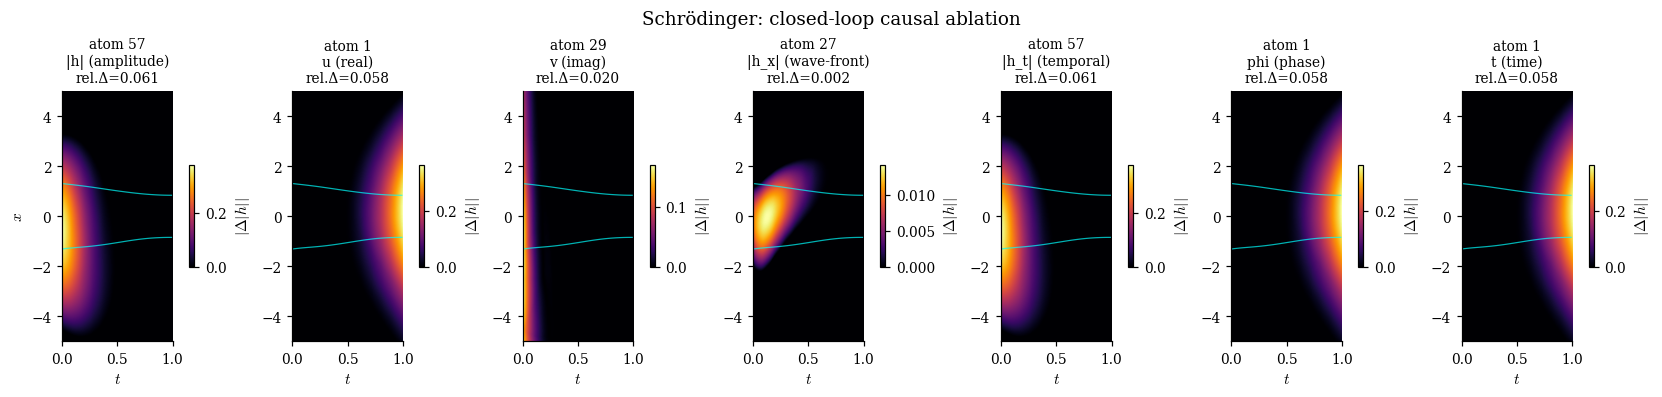

In [ ]:
def intervene_ablate_schrodinger(pinn,sae,H,mu,sd,atom_idx):
    H_flat = H.reshape(-1, HIDDEN)
    H_n = (H_flat - mu)/sd
    Ht = torch.from_numpy(H_n).float()
    with torch.no_grad():
        z = sae.encode(Ht)
        z_mod = z.clone()
        z_mod[:, atom_idx] = 0.0
        h_recon_n = sae.decode(z).numpy()
        h_mod_n   = sae.decode(z_mod).numpy()

    h_recon = h_recon_n * sd + mu
    h_mod   = h_mod_n   * sd + mu
    W = pinn.net[-1].weight.detach().numpy()
    b = pinn.net[-1].bias.detach().numpy()
    uv_recon = h_recon @ W.T + b
    uv_mod   = h_mod   @ W.T + b
    u_recon = uv_recon[:,0].reshape(nx,nt)
    v_recon = uv_recon[:,1].reshape(nx,nt)
    u_mod = uv_mod[:,0].reshape(nx,nt)
    v_mod = uv_mod[:,1].reshape(nx,nt)
    amp_recon = np.sqrt(u_recon**2 + v_recon**2)
    amp_mod = np.sqrt(u_mod**2 + v_mod**2)
    return (amp_recon,amp_mod,amp_recon - amp_mod)
extent_s = [0, 1, -5, 5]

fig, axes = plt.subplots(1,len(sch_concepts_show),figsize=(15, 3.5),constrained_layout=True)

for j_idx, cname in enumerate(sch_concepts_show):
    j = names_s.index(cname)
    k_top = int(np.argmax(np.abs(A_s[:, j])))
    amp_recon, amp_mod, delta = intervene_ablate_schrodinger(pinn_s,sae_s,H_s,mu_s,sd_s,k_top)
    ax = axes[j_idx]
    adelta = np.abs(delta)
    im = ax.imshow(adelta,extent=extent_s,origin="lower",aspect="auto",cmap="inferno",vmin=0,vmax=adelta.max() if adelta.max() > 0 else 1)

    # overlay the soliton
    ax.contour(AMP_s_fig,levels=[1.0],extent=extent_s,origin="lower",colors="cyan",linewidths=0.8,alpha=0.7)
    rel = np.linalg.norm(delta) / (np.linalg.norm(amp_recon) + 1e-12)
    ax.set_title(f"atom {k_top}\n{cname}\nrel.Δ={rel:.3f}",fontsize=9)
    ax.set_xlabel("$t$")

    if j_idx == 0:
        ax.set_ylabel("$x$")

    plt.colorbar(im,ax=ax,fraction=0.046,label=r"$|\Delta |h||$")
plt.suptitle("Schrödinger: closed-loop causal ablation",fontsize=12)
plt.savefig("figures/fig4_schrodinger_intervention.png",bbox_inches="tight")
plt.show()

# 9. Figure 5 — Training dynamics and SAE-vs-PCA bar chart

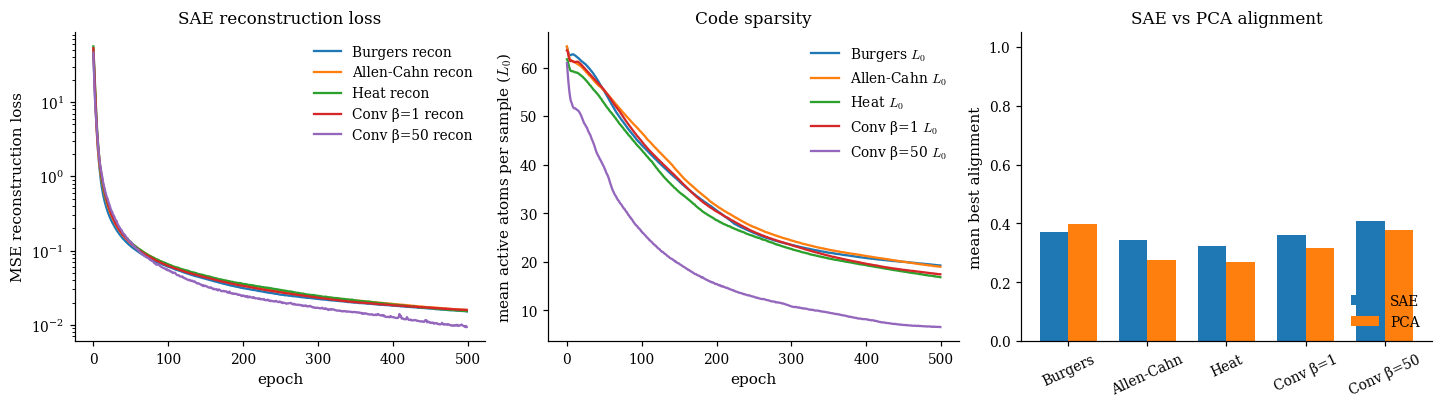

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13.0, 3.6), constrained_layout=True)
ax = axes[0]
ax.plot(sae_hist_b[:,1], label="Burgers recon")
ax.plot(sae_hist_a[:,1], label="Allen-Cahn recon")
ax.plot(sae_hist_h[:,1],   label="Heat recon")
ax.plot(sae_hist_c1[:,1],  label="Conv β=1 recon")
ax.plot(sae_hist_c50[:,1], label="Conv β=50 recon")
ax.set_yscale("log"); ax.set_xlabel("epoch"); ax.set_ylabel("MSE reconstruction loss")
ax.set_title("SAE reconstruction loss"); ax.legend(frameon=False)

ax = axes[1]
ax.plot(sae_hist_b[:,3],   label="Burgers $L_0$")
ax.plot(sae_hist_a[:,3],   label="Allen-Cahn $L_0$")
ax.plot(sae_hist_h[:,3],   label="Heat $L_0$")
ax.plot(sae_hist_c1[:,3],  label="Conv β=1 $L_0$")
ax.plot(sae_hist_c50[:,3], label="Conv β=50 $L_0$")
ax.set_xlabel("epoch"); ax.set_ylabel(r"mean active atoms per sample ($L_0$)")
ax.set_title("Code sparsity"); ax.legend(frameon=False)

ax = axes[2]
tags = ["Burgers","Allen-Cahn","Heat","Conv β=1","Conv β=50"]
sae_scores = [
    np.max(np.abs(A_b), axis=1).mean(),
    np.max(np.abs(A_a), axis=1).mean(),
    np.max(np.abs(A_h), axis=1).mean(),
    np.max(np.abs(A_c1), axis=1).mean(),
    np.max(np.abs(A_c50), axis=1).mean()
]

pca_scores = [
    np.max(np.abs(A_pca_b), axis=1).mean(),
    np.max(np.abs(A_pca_a), axis=1).mean(),
    np.max(np.abs(A_pca_h), axis=1).mean(),
    np.max(np.abs(A_pca_c1), axis=1).mean(),
    np.max(np.abs(A_pca_c50), axis=1).mean()
]

xb = np.arange(len(tags))
ax.bar(xb-0.18,sae_scores,width=0.36,label="SAE")
ax.bar(xb+0.18,pca_scores,width=0.36,label="PCA")
ax.set_xticks(xb)
ax.set_xticklabels(tags, rotation=25)
ax.set_ylim(0,1.05)
ax.set_ylabel("mean best alignment")
ax.set_title("SAE vs PCA alignment")
ax.legend(frameon=False)
ax.legend(frameon=False, loc="lower right")
plt.savefig("figures/fig5_sparsity_baseline.png", bbox_inches="tight"); plt.show()
